In [1]:
import numpy as np
import pylab
import math
import matplotlib.pyplot as plt
from matplotlib import rcParams
#from pyunicorn.core import Network
from pyunicorn.timeseries import RecurrenceNetwork
from pyunicorn.timeseries import RecurrencePlot
from pyunicorn.core import Network
import networkx as nx
rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = [9, 6]
import sys,os, shutil
import pyvo as vo
# Ignore unimportant warnings
import warnings
warnings.filterwarnings('ignore', '.*Unknown element mirrorURL.*', vo.utils.xml.elements.UnknownElementWarning)
from packaging import version
import importlib
import pandas as pd
import subprocess as sb
import glob


def show_graph(adjacency_matrix):
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=0.5, edge_color='r', width=0.01, with_labels=False)
    plt.show()

def open_file(rootfilename, length):
    surro_DET = []
    surro_LAM = []
    for i in range(1,10):
        file = rootfilename + "_00" + str(i) 
        print(file)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension, tau=t_min, metric="euclidean", threshold=thr, normalize=True)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=length)
        LAMsur = surro_rp_data.laminarity(v_min=length)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        data = []
    for j in range (10, 40):
        file = rootfilename + "_0" + str(j)
        print(file)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension , tau=t_min,  metric="euclidean", threshold=thr, normalize=True)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=length)
        LAMsur = surro_rp_data.laminarity(v_min=length)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        data = []      
    return surro_DET, surro_LAM
    
def lcurve(p):
    fig1, ax = plt.subplots(1)
    print("RQA  {}".format(p))
    lc = p
    ax.plot(lc, color='Blue')
    j = lc
    return j


def RP_RN(l, i):
    qpo_rp = RecurrencePlot(l, dim=dimension , tau=t_min, metric = "euclidean", threshold=thr, normalize=True)
    # qpo_rp_rn = RecurrenceNetwork(j, dim=10, tau=2,metric = "euclidean", threshold=3, normalize=True)
    pylab.matshow(qpo_rp.recurrence_matrix())
    pylab.xlabel("$n$")
    pylab.ylabel("$n$")
    RRqpo = qpo_rp.recurrence_rate()
    DETqpo = qpo_rp.determinism(l_min=2)
    LAMqpo = qpo_rp.laminarity(v_min=2)
    ENTR = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
    f = open("data", "a")
    f.write("RQA for {}\n Determinism:{}, Recurrence rate:{}, Laminarity:{}, ENT: {} \n".format(i, DETqpo, RRqpo,LAMqpo,ENTR))
    f.close()
    #show_graph(qpo_rp_rn.adjacency)
    return DETqpo, RRqpo

def sur_test(l, m):
    os.system("./surrogates s/qp -n40 -o -V0")
    a, b = open_file("s/qp_surr", 2)
    fig2, axs = plt.subplots(1)
    fig2.suptitle('Surrogate test PSei')
    axs.plot(a, label = 'DET of the each surrogate data')
    c, d = RP_RN(l, m)
    axs.axhline(y = c, color = 'r', linestyle = '-', label = 'DET of the original data' )
    axs.legend(loc='lower right')
    axs.set_xlabel("Surrogate data set no. ")
    axs.set_ylabel("DET")
    fig2.savefig('n/surro.jpg', format="jpg")

In [2]:
import networkx as nx
def show_graph(adjacency_matrix):
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=0.5, edge_color='r', width=0.01, with_labels=False)
    plt.show()

In [3]:
data1 = np.loadtxt("psei.csv", delimiter =',', usecols =(1) , skiprows=1)*1000
data2 = np.loadtxt("psei.csv", delimiter =',', usecols =(2) , skiprows=1)
data = data1 + data2
np.savetxt("s/qp", data)

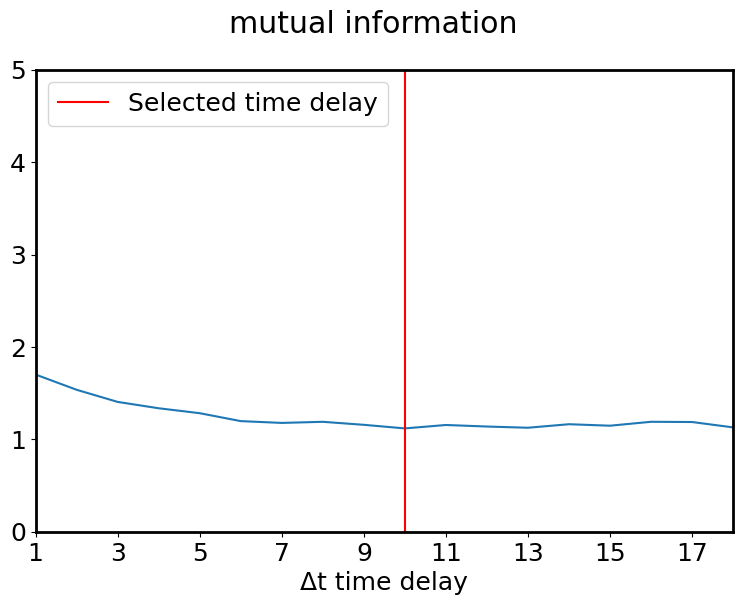

In [4]:
os.system("./mutual s/qp -o files/mutual_stocks -V0")
m_site1 = np.loadtxt("files/mutual_stocks", delimiter =' ', usecols =(1) , skiprows=0)
fig2, axs = plt.subplots(1)
fig2.suptitle("mutual information")
axs.plot(m_site1)
plt.axvline(x = 10, color = 'red', label = 'Selected time delay')
plt.xticks(range(1,21,2))
axs.set_xlim([1, 18])
axs.set_ylim([0, 5])
plt.xlabel("Δt time delay")
plt.legend()
for spine in axs.spines.values():
    spine.set_linewidth(2)
plt.show()

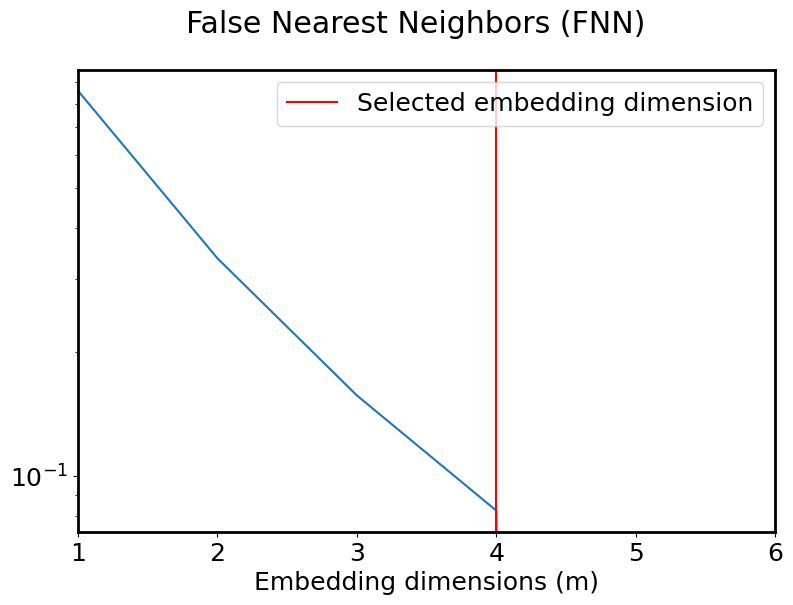

In [5]:
os.system("./false_nearest s/qp -o -m1 -d10 files/stocks -V0")
m1 = np.loadtxt("files/stocks.fnn", usecols=1)
d1 = np.loadtxt("files/stocks.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1/d1)
ax.set_yscale("log")
plt.xticks(range(1,20,1))
plt.xlabel("Embedding dimensions (m)")
plt.axvline(x = 4, color = 'red', label = 'Selected embedding dimension')
ax.set_xlim([1, 6])
plt.legend()
# ax.set_ylim([0, 0.35])
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.show()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
0.9214925373120575 0.13560184822617277 0.9516315333512105 2.1406644811720663


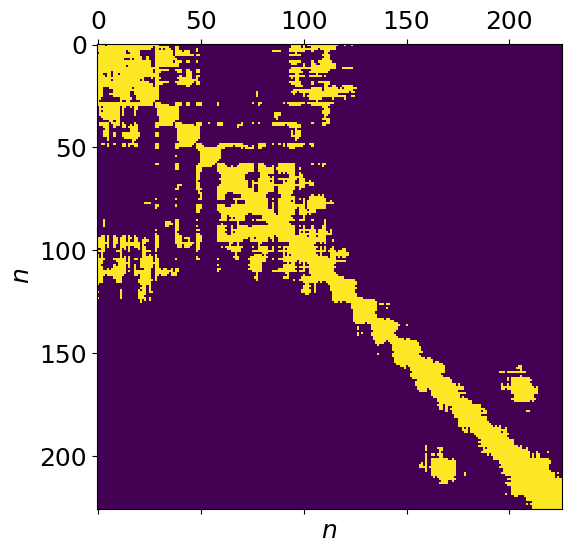

In [5]:
dimension = 4
thr = 0.7
t_min=10
qpo_rp = RecurrencePlot(data, dim=dimension, tau=t_min, metric = "euclidean", threshold=thr, normalize=True)
pylab.matshow(qpo_rp.recurrence_matrix())
pylab.xlabel("$n$")
pylab.ylabel("$n$")
RRqpo = qpo_rp.recurrence_rate()
DETqpo = qpo_rp.determinism(l_min=2)
LAMqpo = qpo_rp.laminarity(v_min=2)
ENTR = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
print(DETqpo, RRqpo, LAMqpo, ENTR)

RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.49 7730.57 7689.91 7230.57 7294.38 7215.7

0.2700000000000001 0.019187093742658
RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.49 7

/tmp/ipykernel_14315/1935799891.py:61: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1, ax = plt.subplots(1)


0.3100000000000001 0.025334795207142297
RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.4

0.38000000000000017 0.037199467460255306
RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.

0.45000000000000023 0.05231419844936957
RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.4

RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.49 7730.57 7689.91 7230.57 7294.38 7215.7

RQA  [6528.79 6613.85 7142.96 7272.65 6897.54 6619.09 6411.91 6433.1  6700.49
 6903.53 6944.71 6646.44 6450.04 6223.73 5973.78 6321.24 6175.25 6591.47
 6468.07 6477.36 6625.08 6499.68 6556.2  6793.25 6566.39 6780.78 6153.43
 5741.07 6583.65 6315.93 6155.43 6774.68 6731.25 7203.47 7311.01 7361.65
 7122.63 7200.88 7054.7  6952.88 6855.44 6270.23 6901.91 6628.49 6370.87
 6443.09 6794.86 6612.62 7139.71 6791.46 6324.   5864.23 5884.18 5928.45
 6207.72 5838.84 5700.71 5321.23 6787.91 7200.79 7815.26 7738.96 7977.12
 7779.07 7979.66 8045.8  7999.71 7970.02 7952.72 7920.93 7705.49 8007.48
 7466.02 7367.85 7140.29 7276.82 7855.71 7672.   7193.68 7497.17 7819.25
 7979.83 8475.29 8764.01 8558.42 8254.03 8365.26 8171.43 7958.57 8018.05
 7843.16 7837.12 7661.01 7311.72 7212.09 7229.66 6840.64 6781.2  7404.8
 7629.73 7787.37 7963.11 7796.25 7401.6  7159.29 7262.3  6671.04 6687.62
 6952.08 6927.07 7134.26 6893.98 7098.81 7550.   7564.5  7580.46 7714.82
 7940.49 7730.57 7689.91 7230.57 7294.38 7215.7

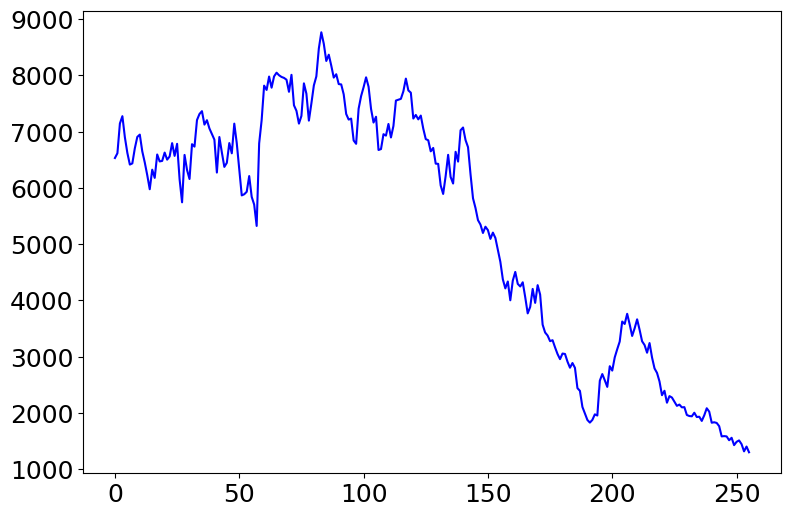

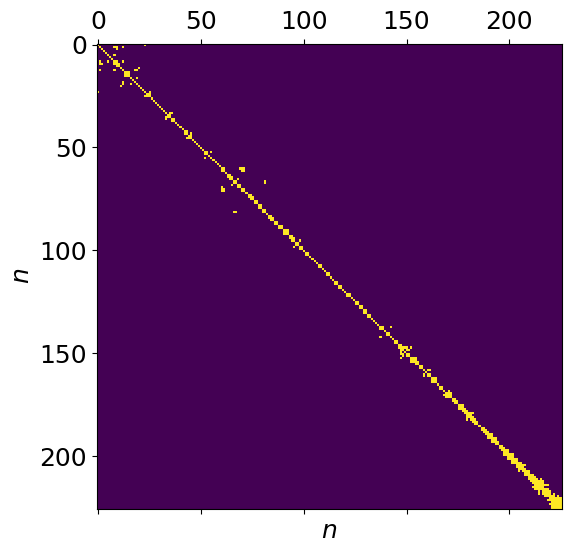

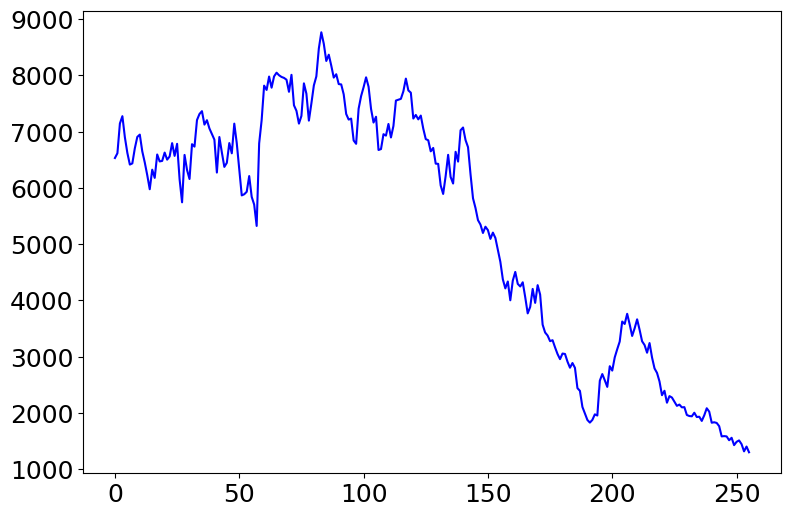

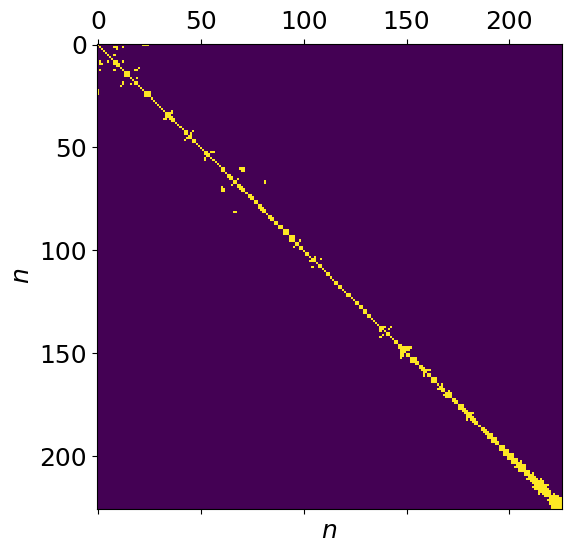

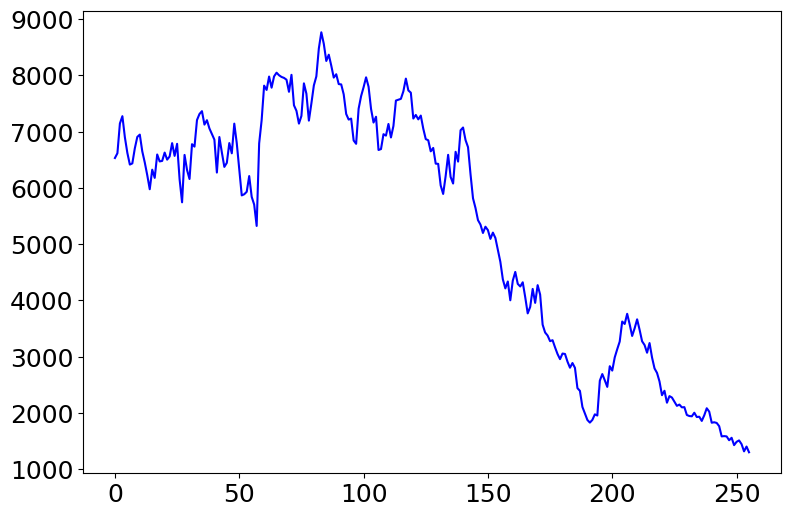

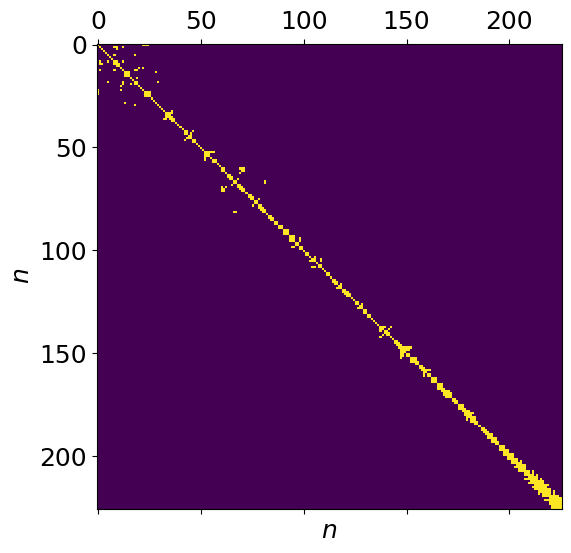

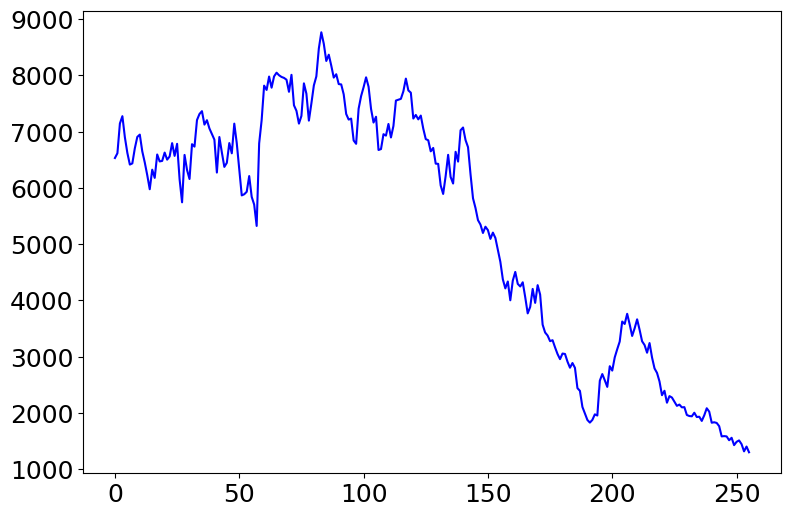

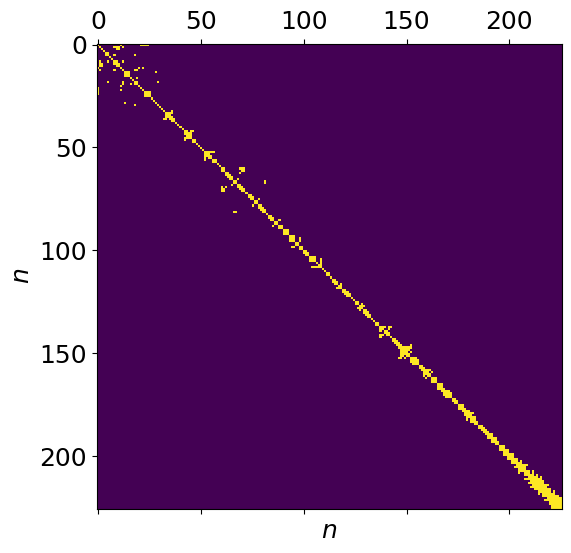

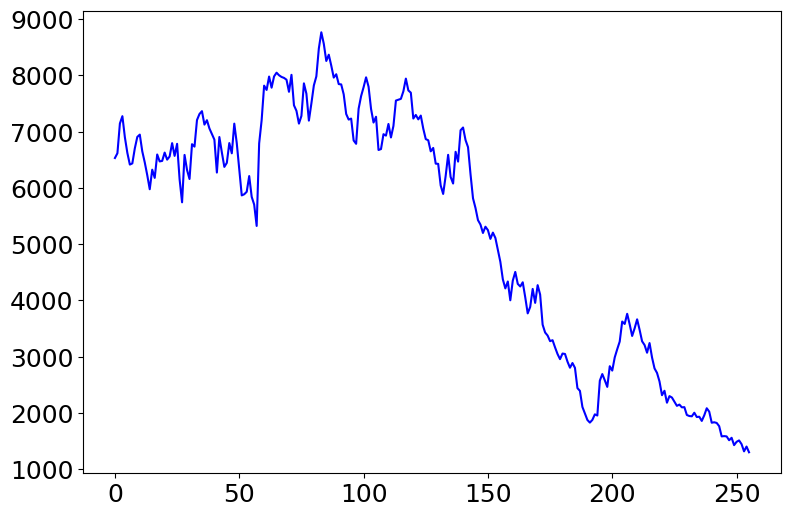

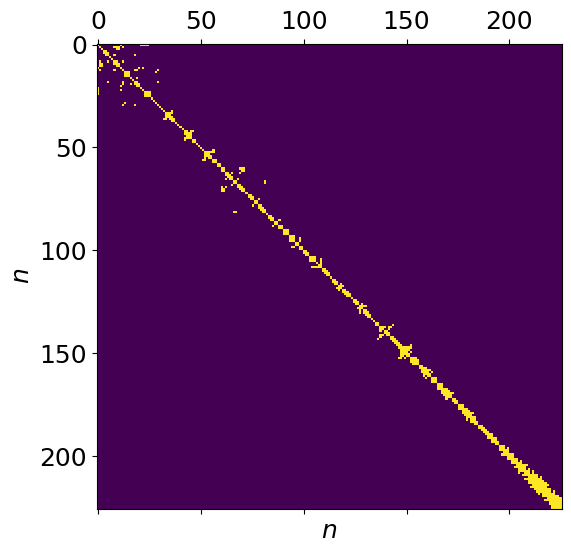

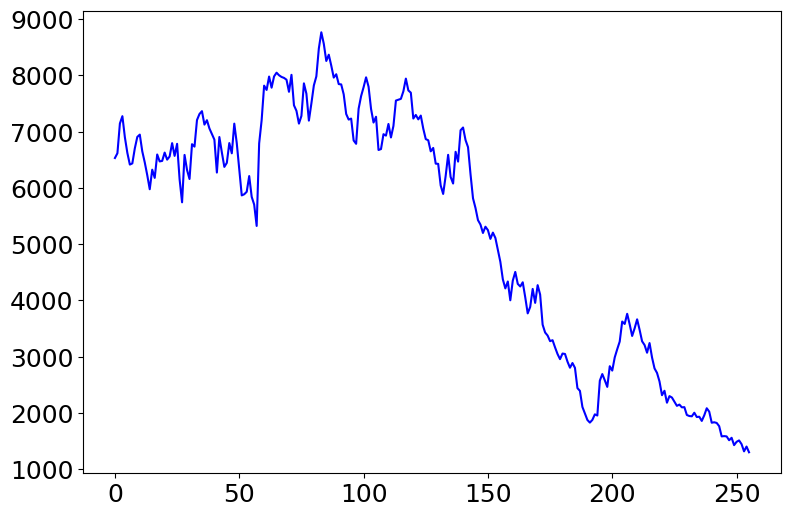

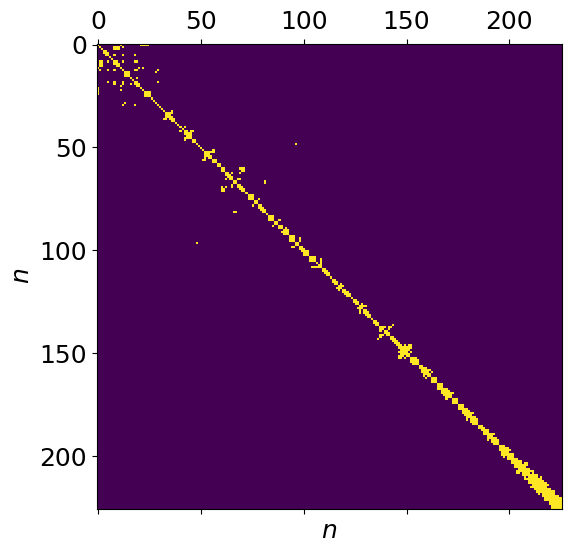

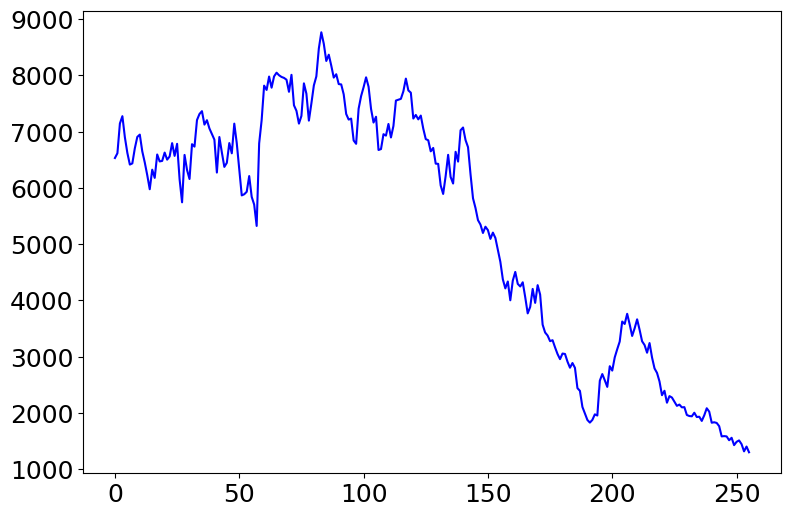

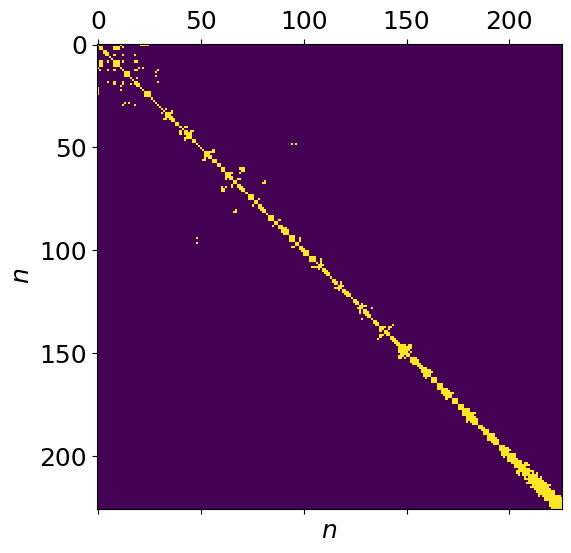

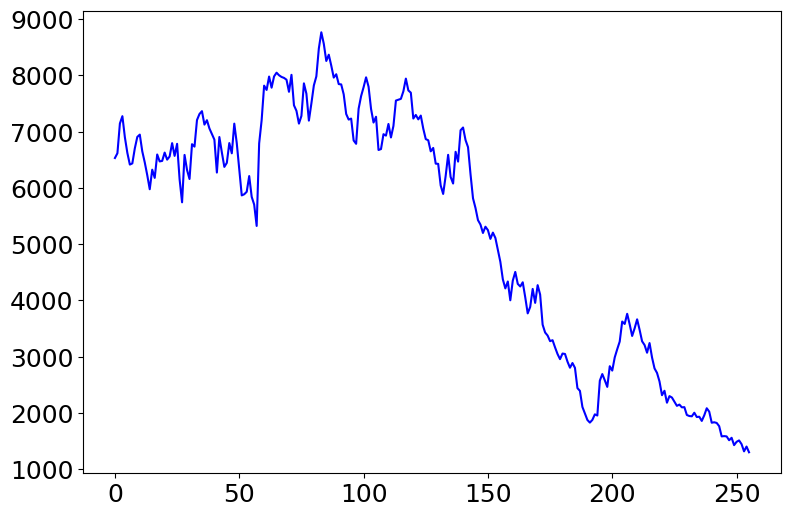

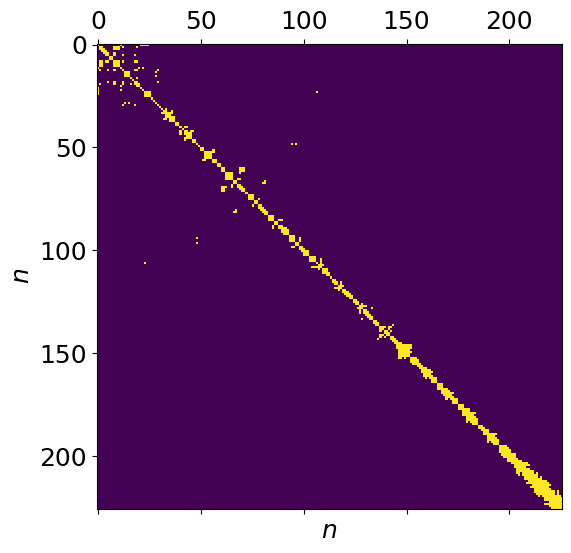

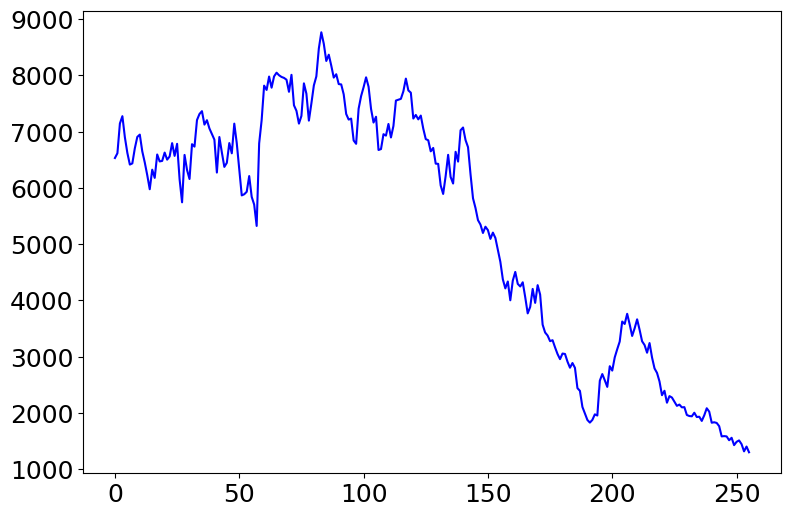

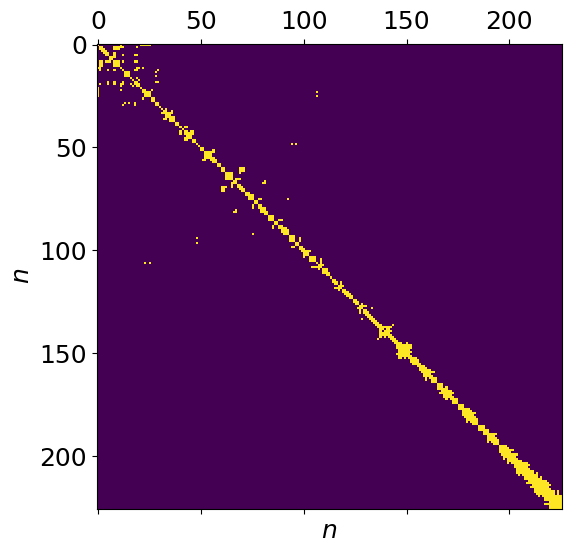

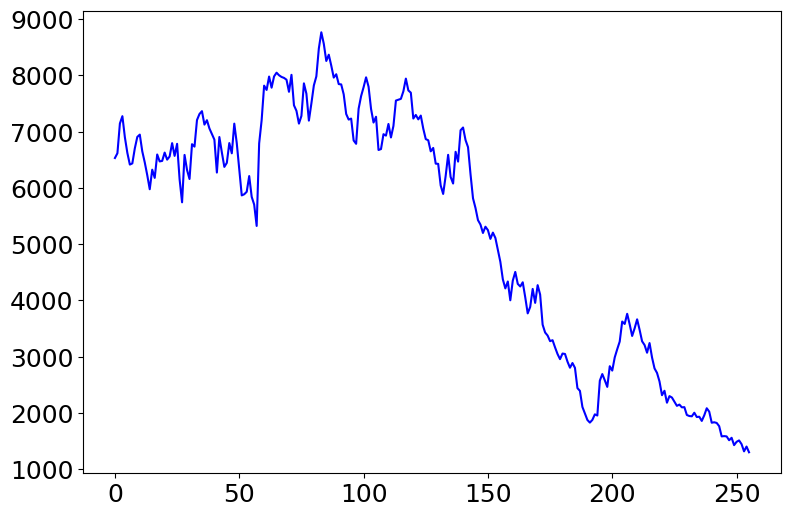

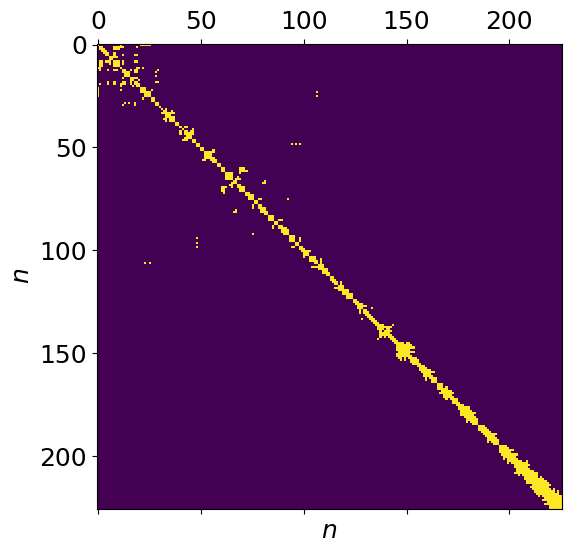

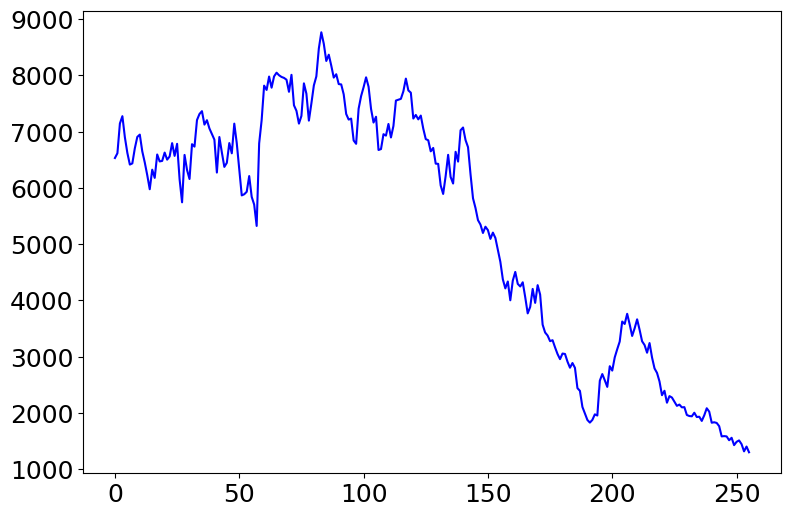

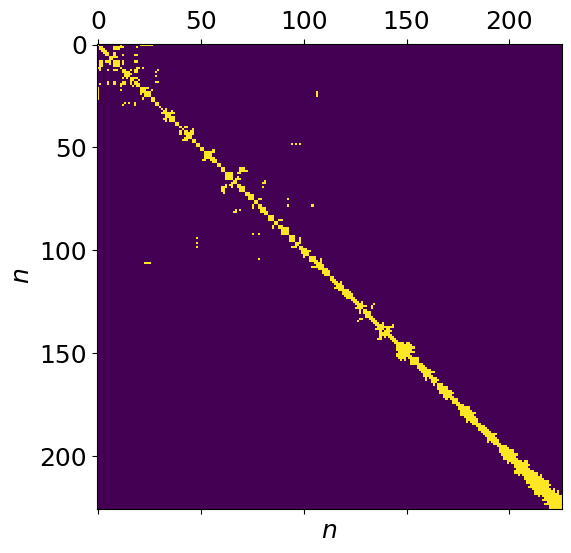

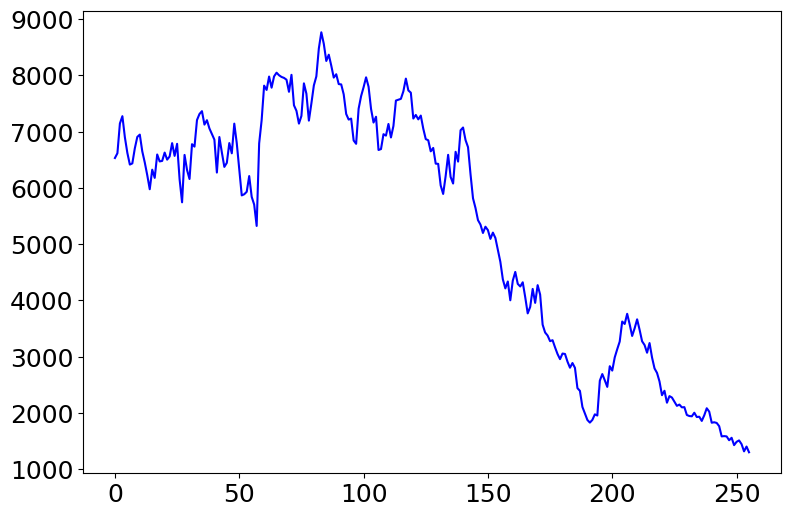

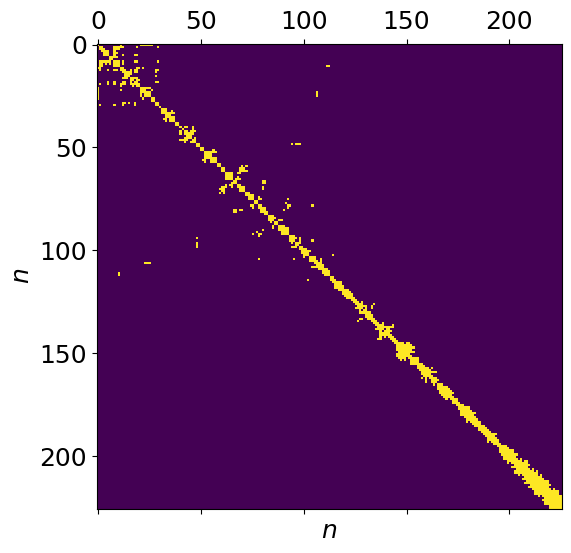

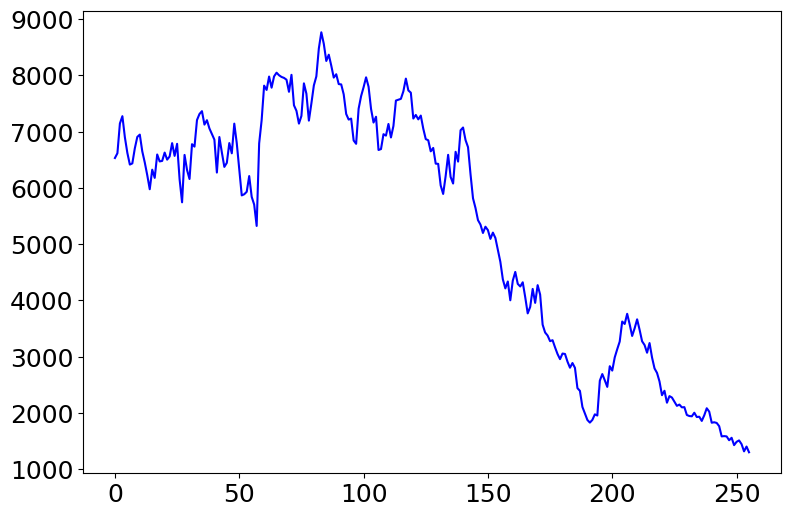

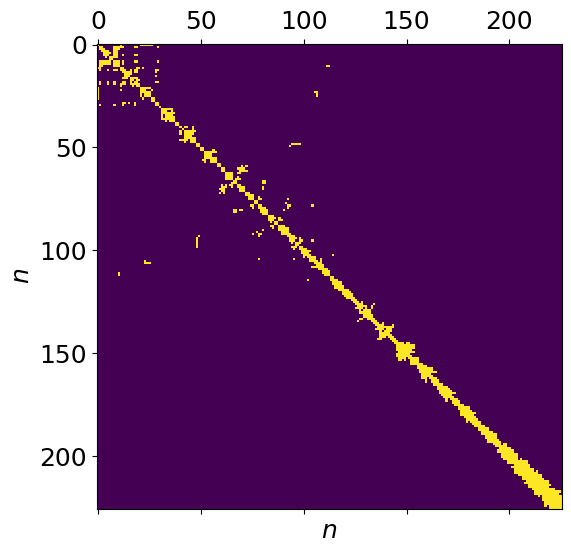

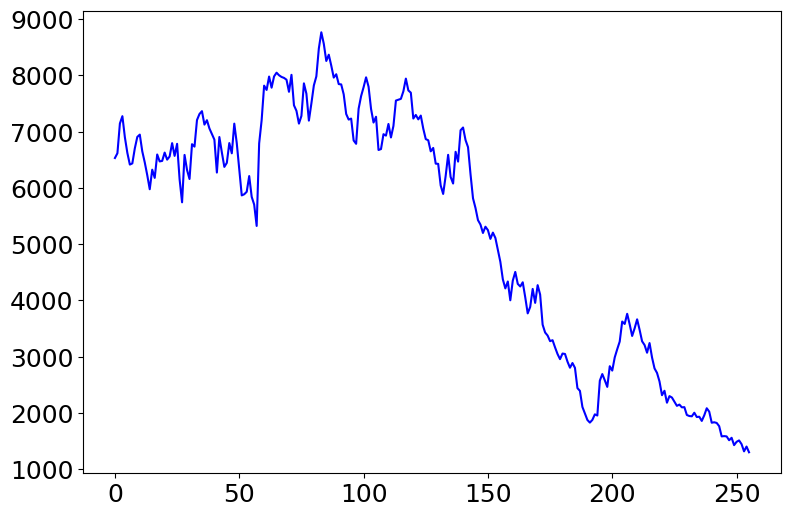

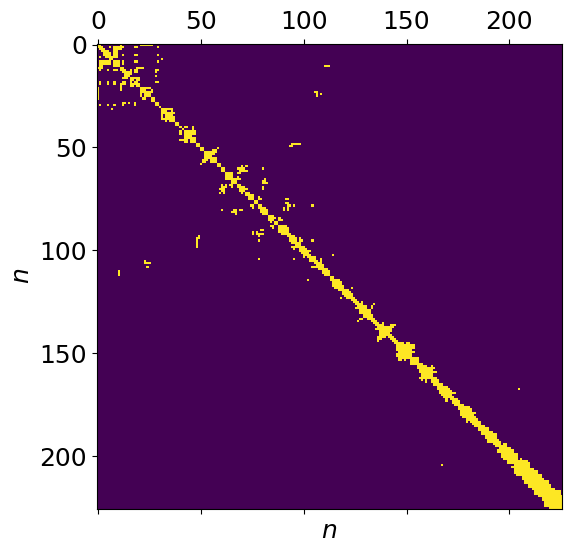

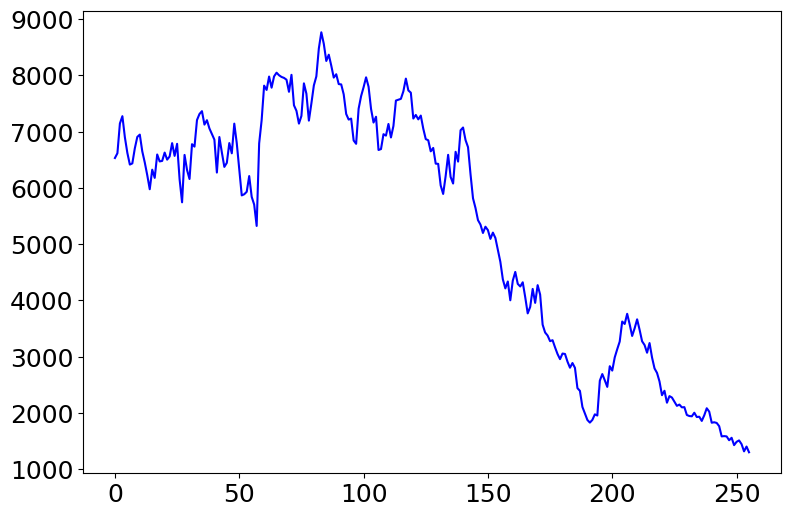

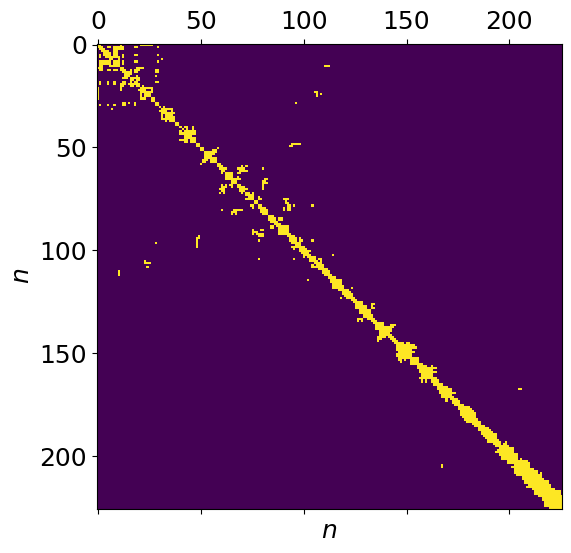

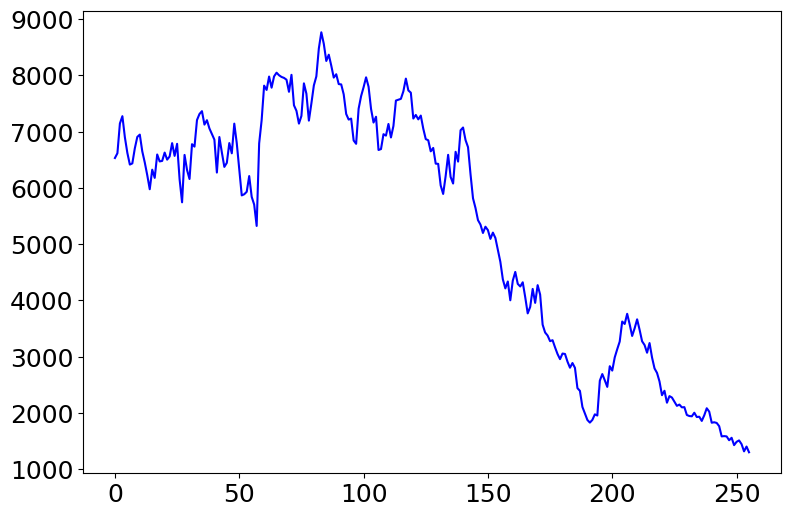

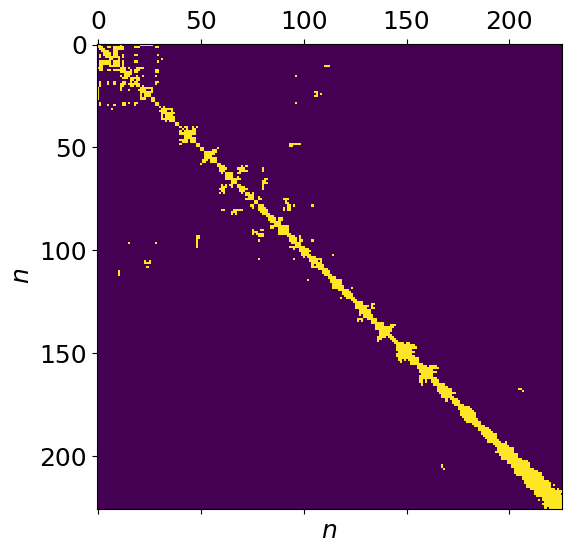

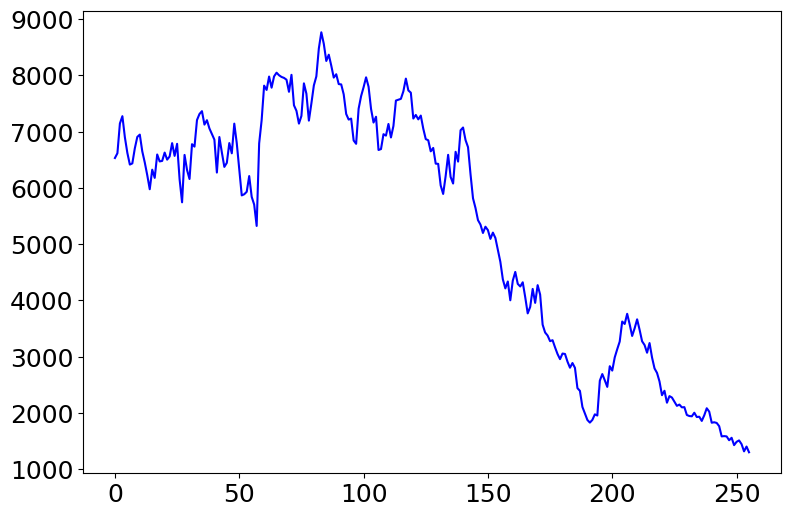

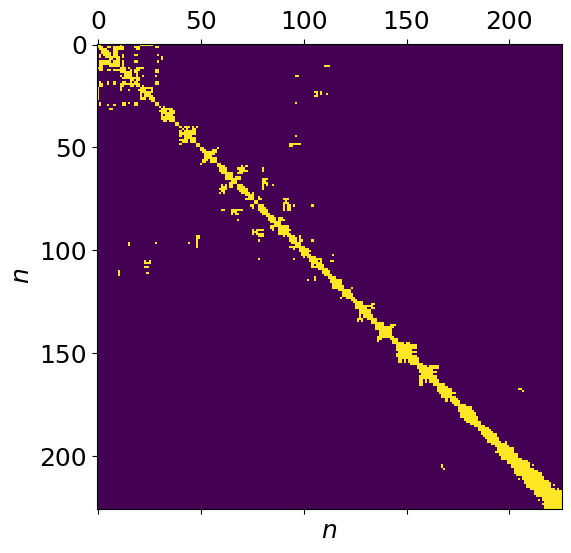

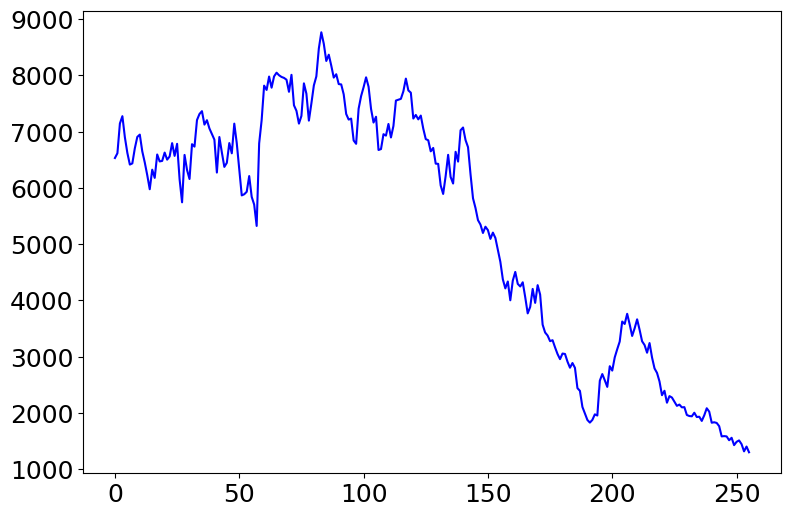

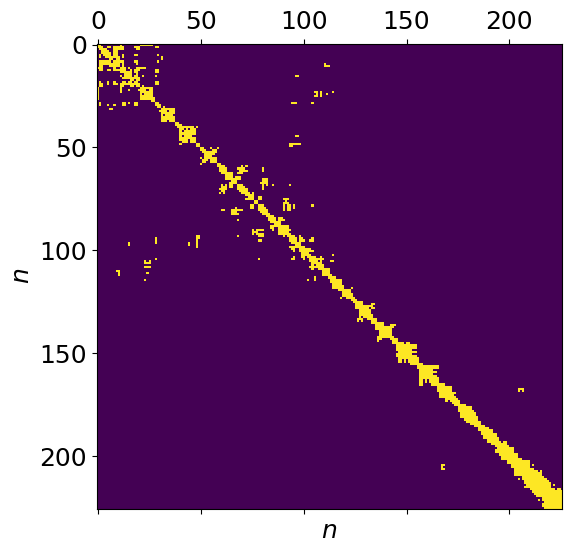

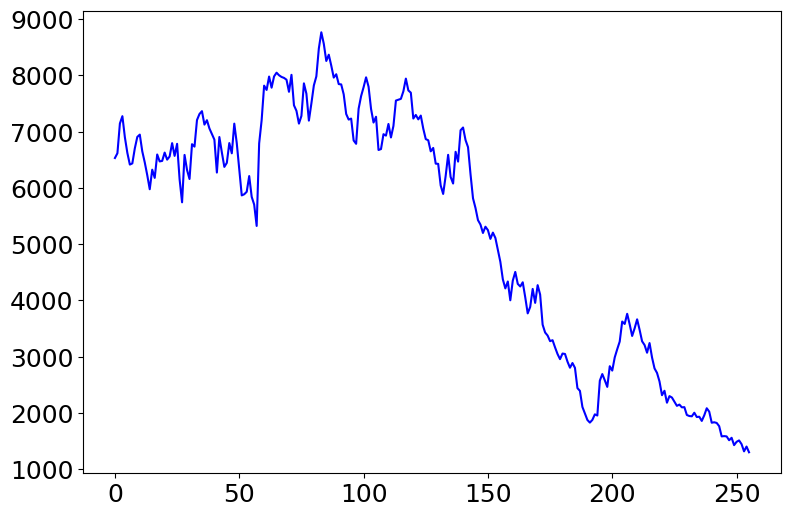

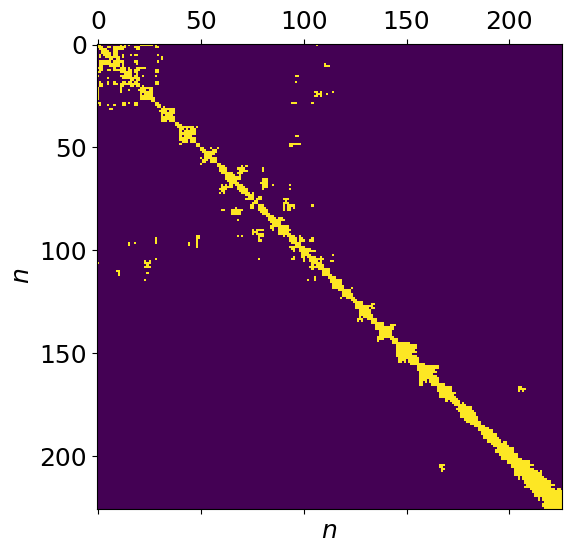

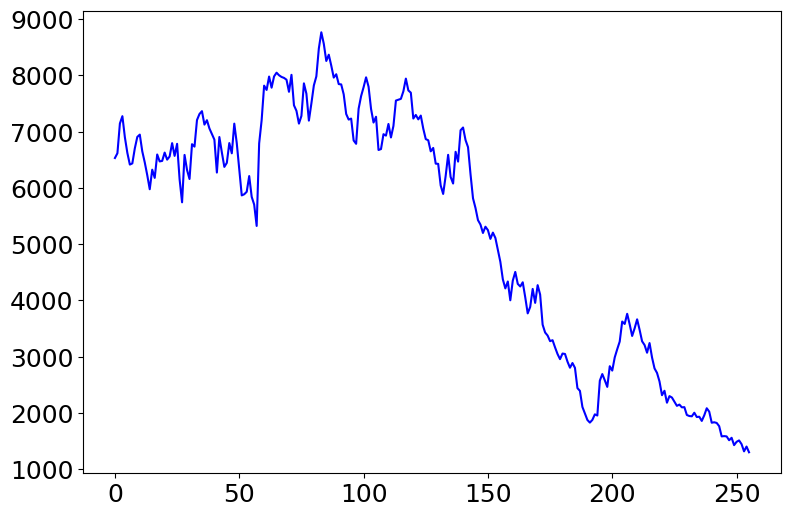

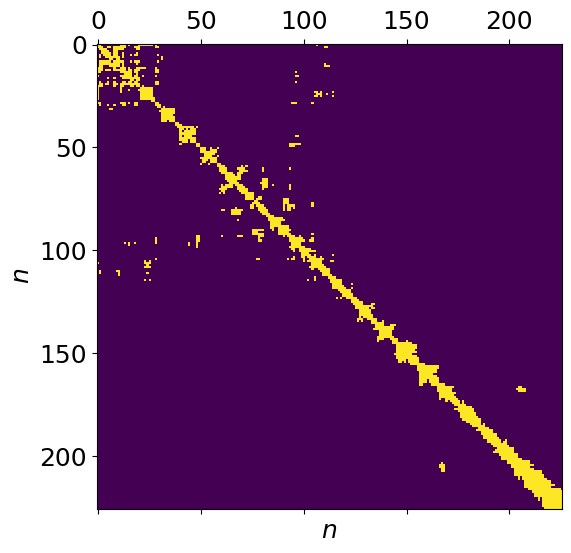

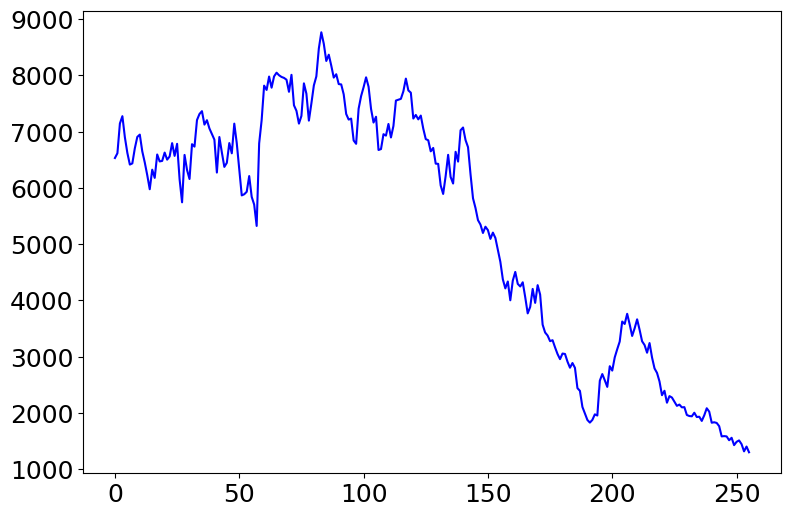

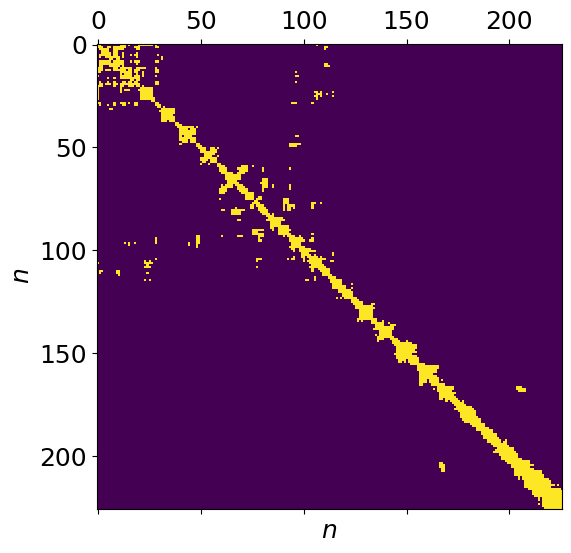

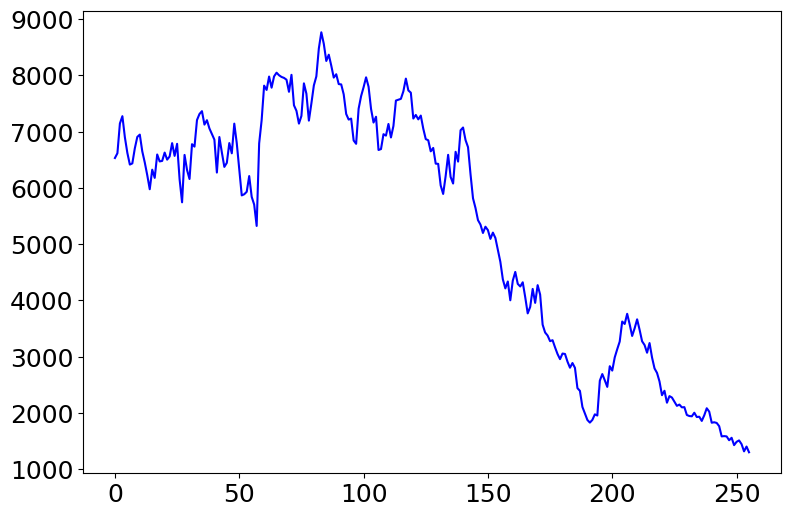

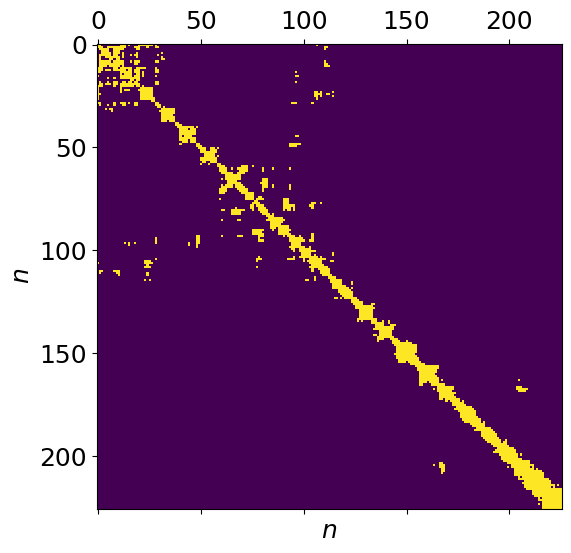

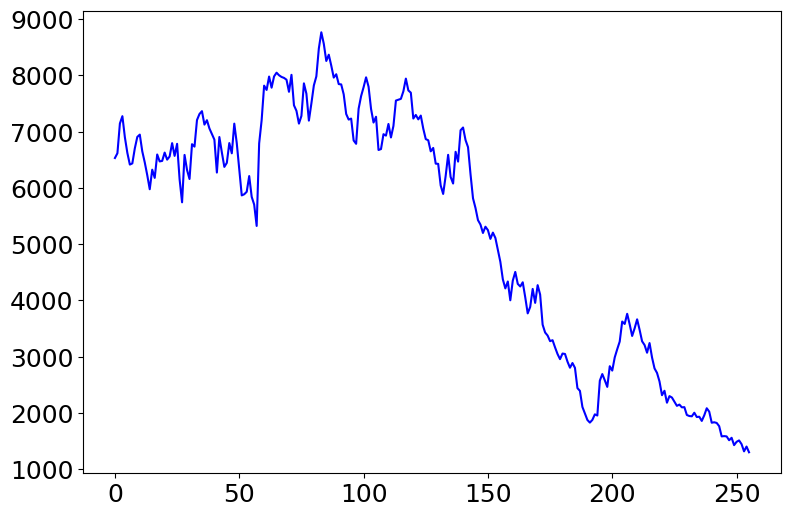

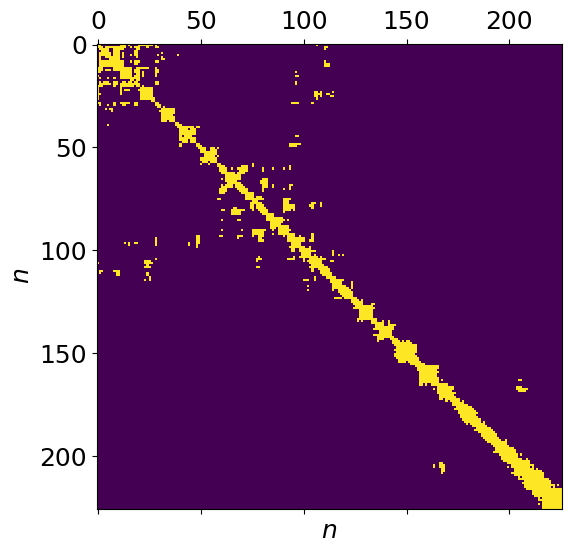

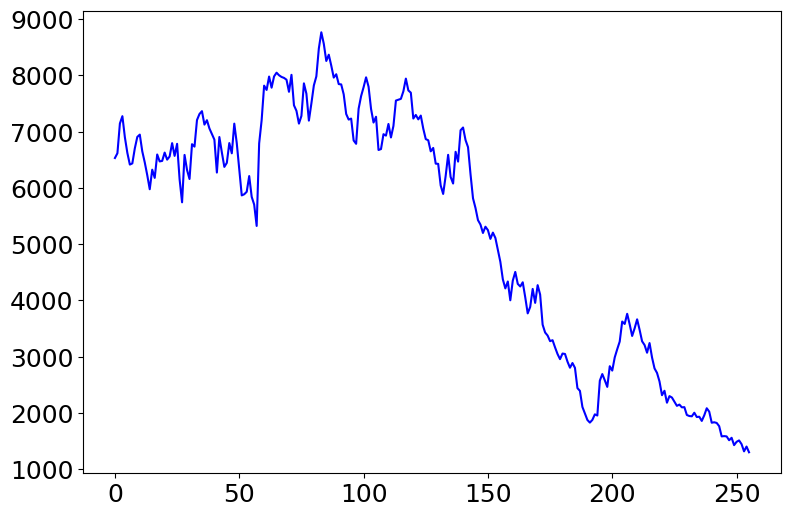

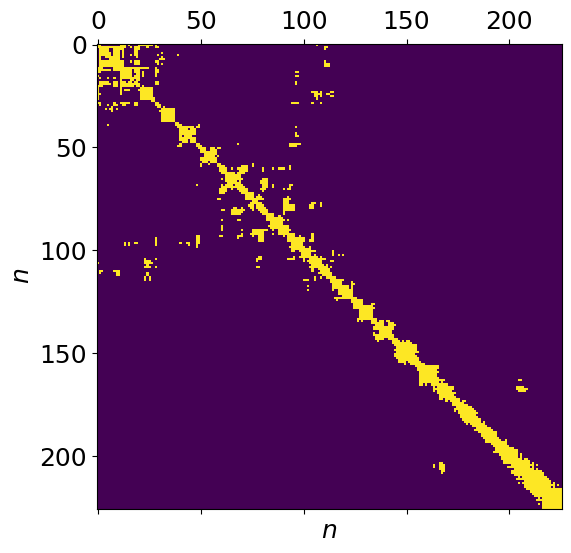

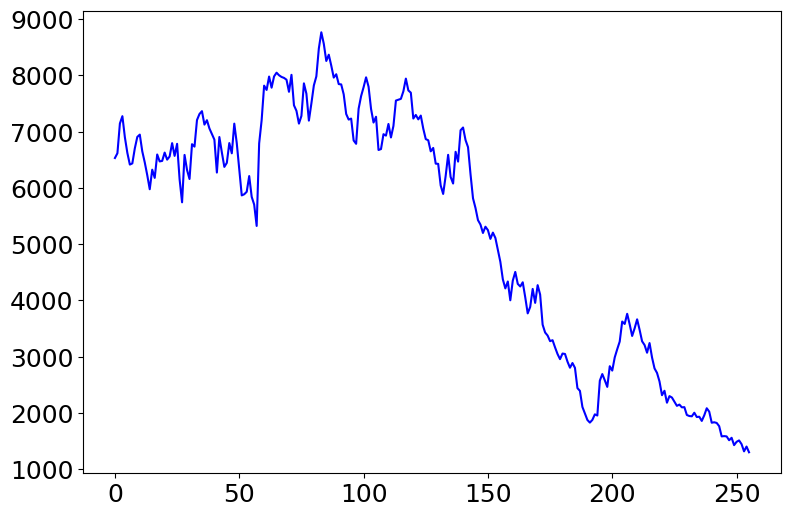

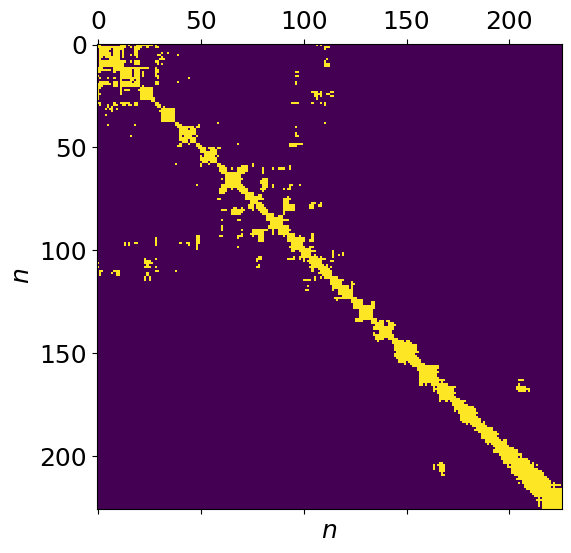

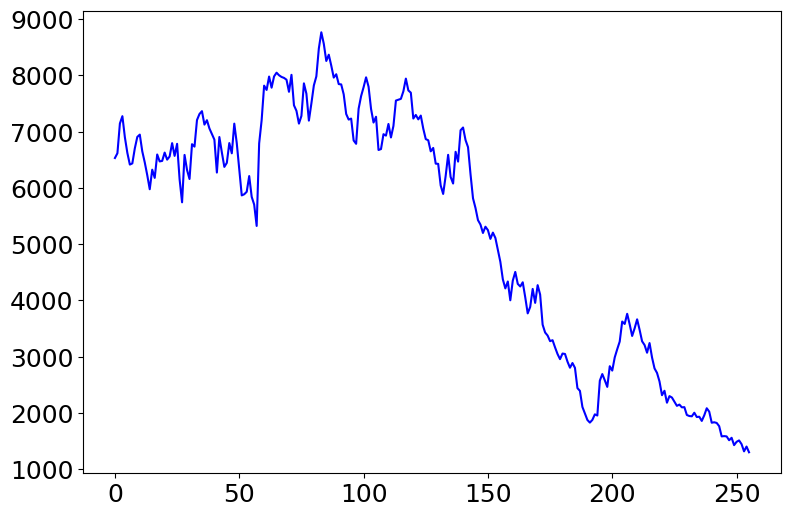

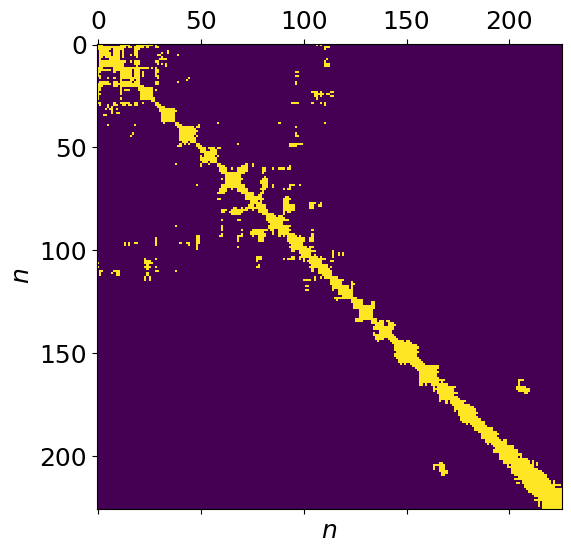

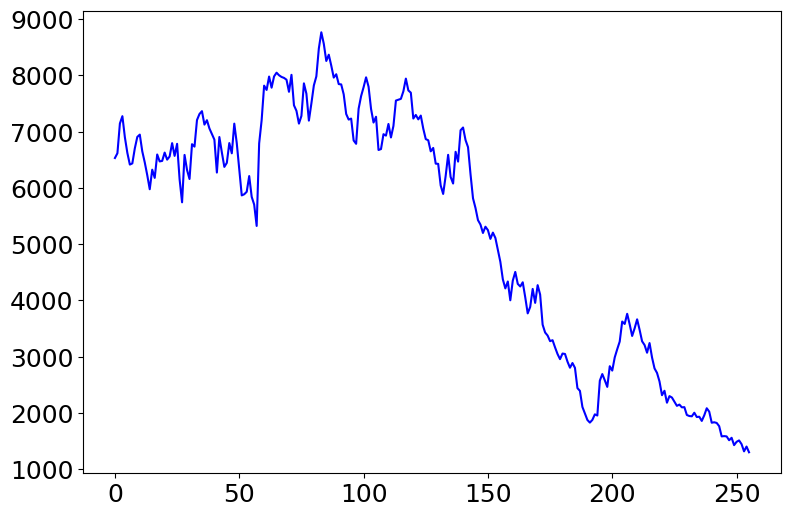

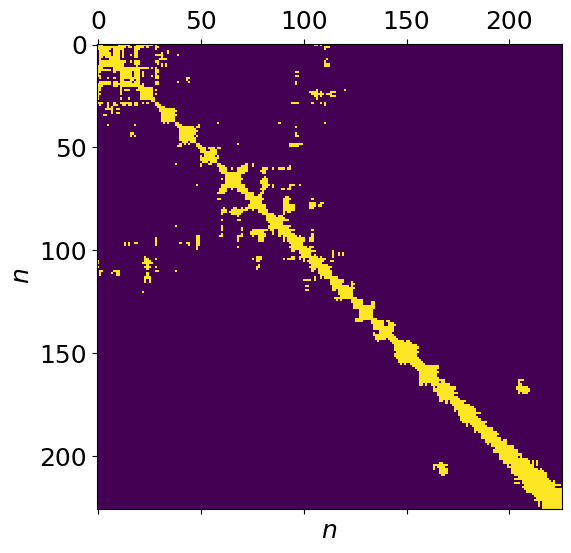

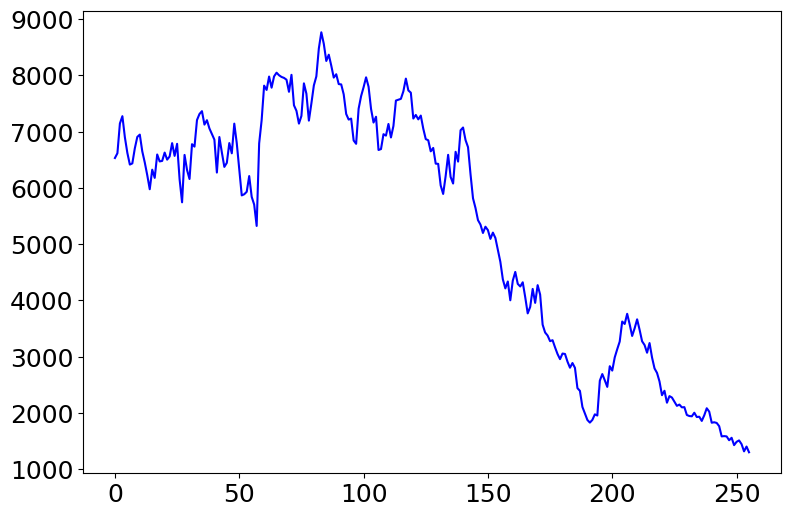

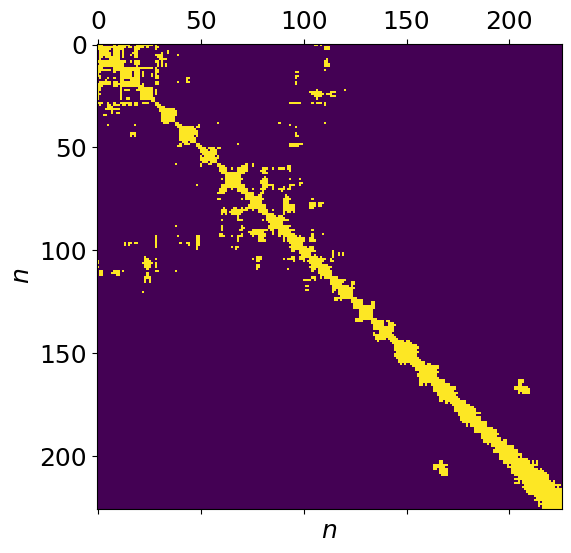

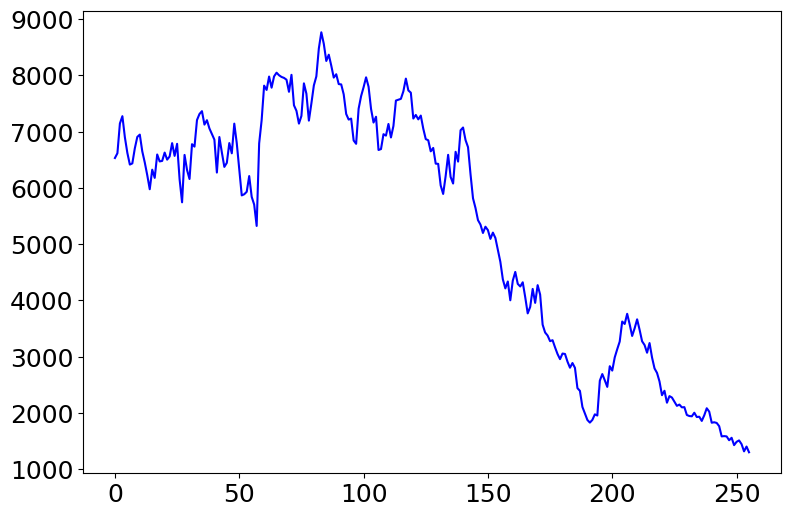

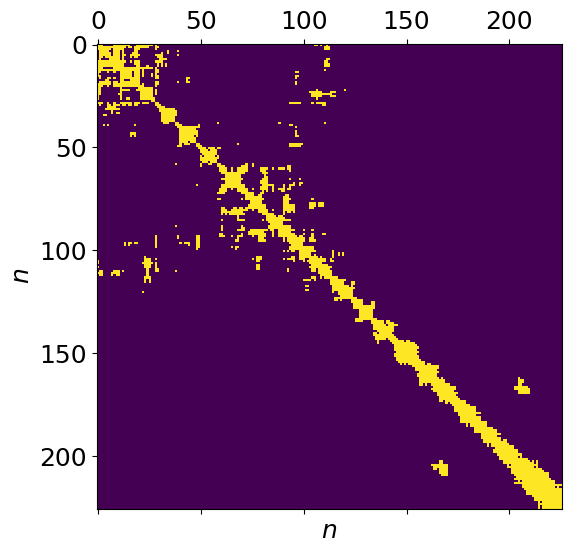

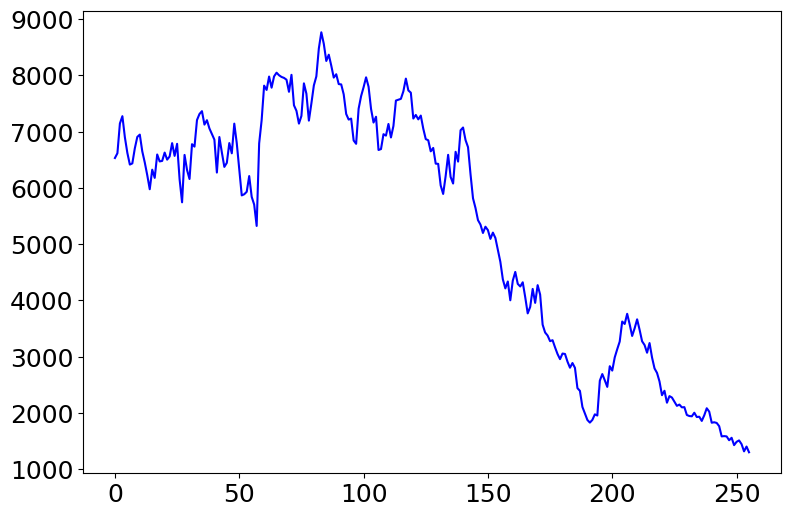

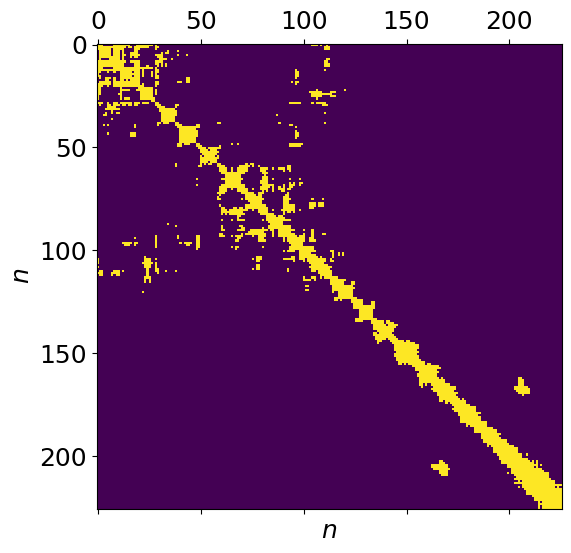

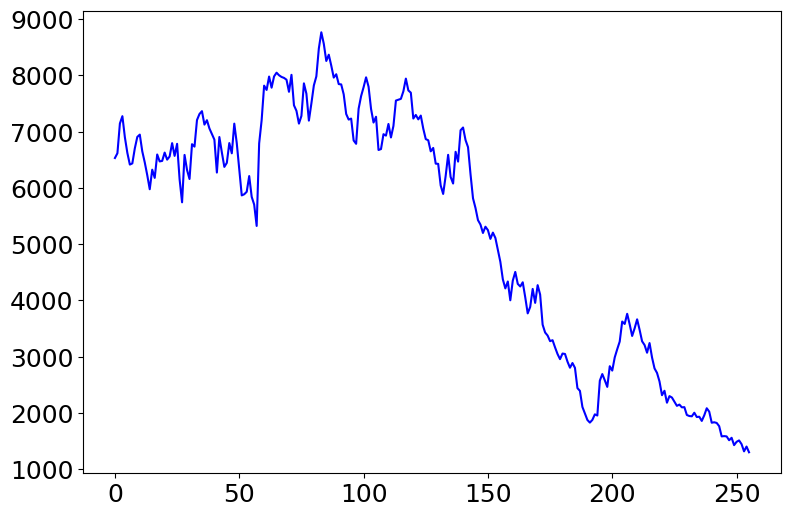

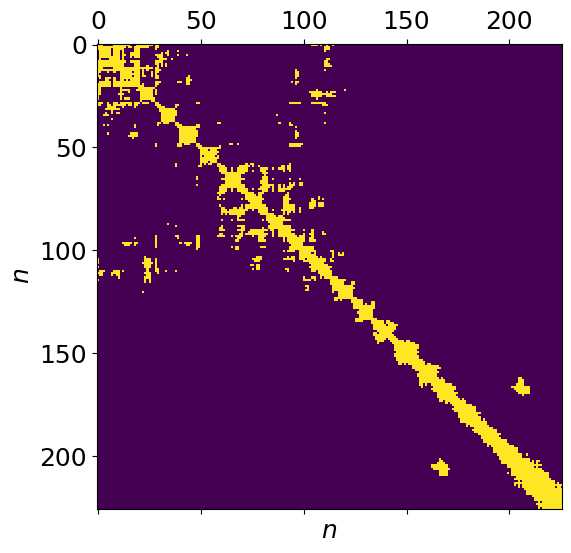

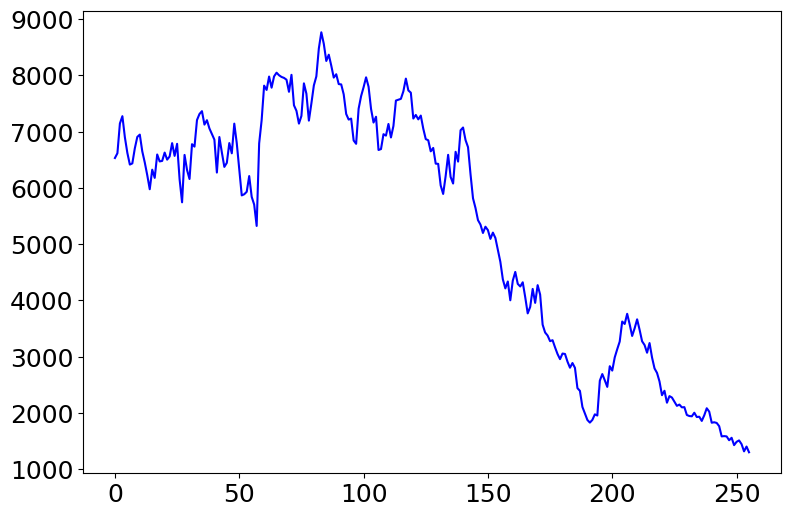

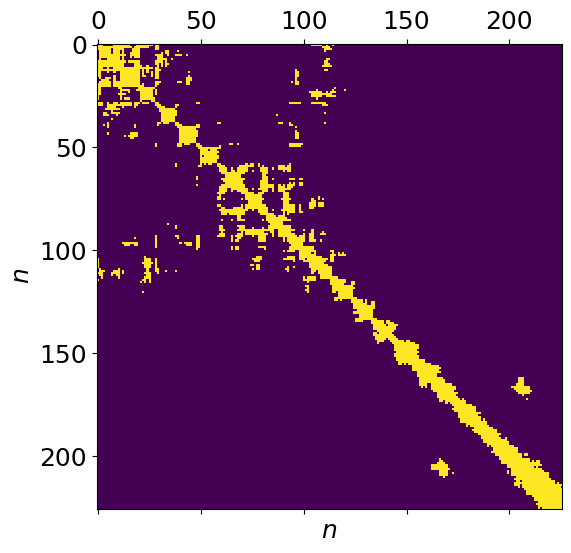

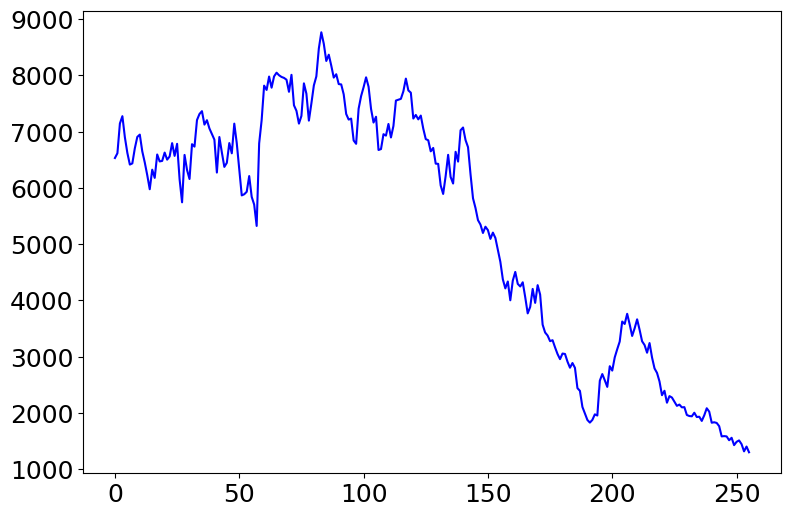

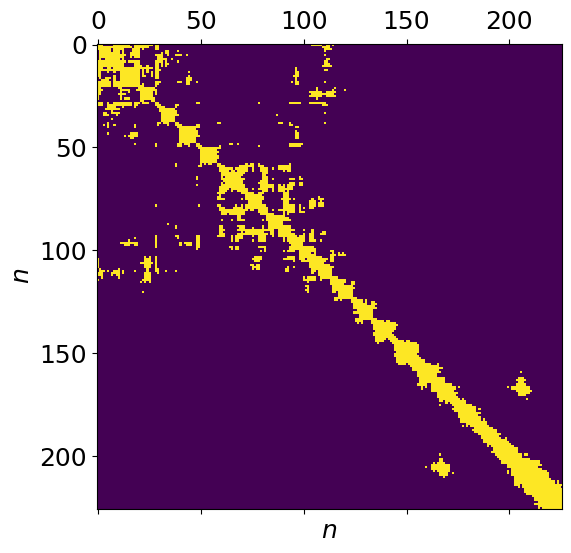

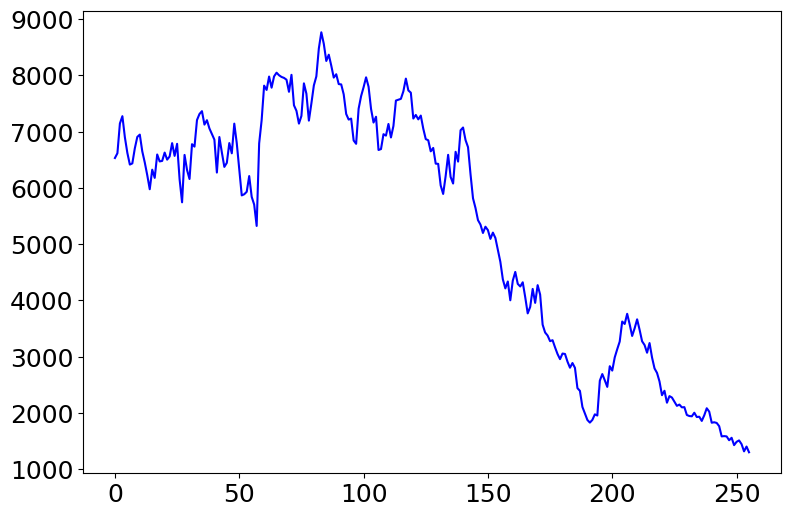

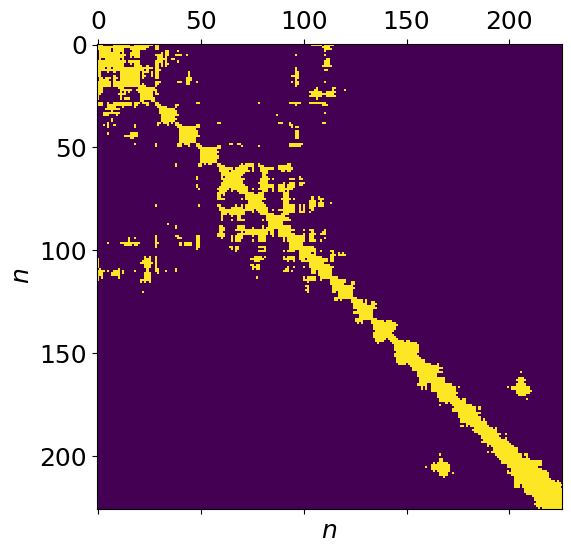

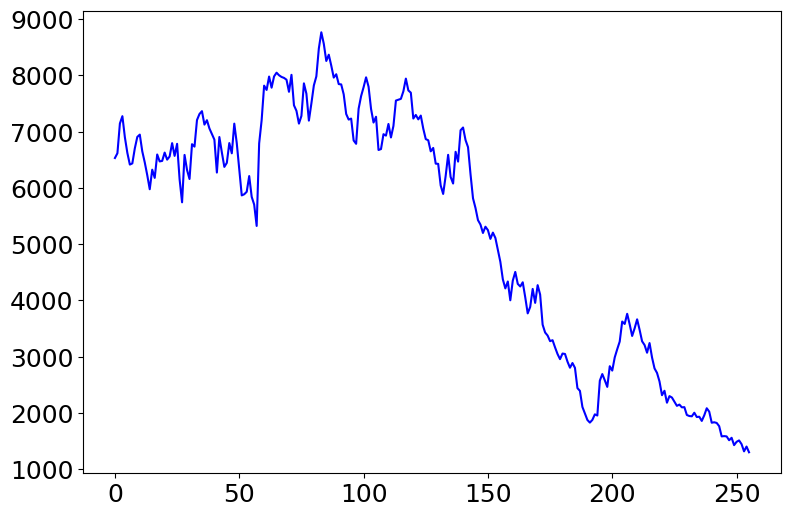

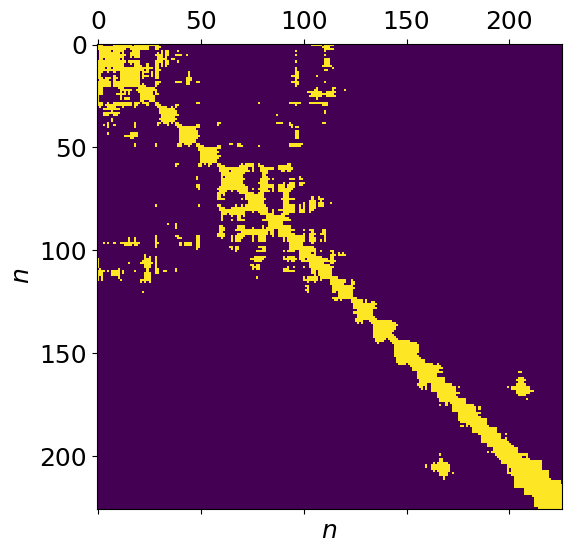

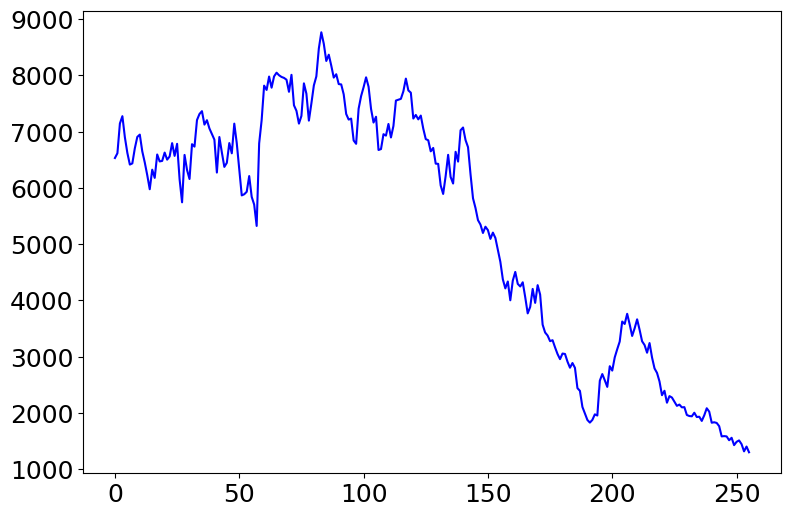

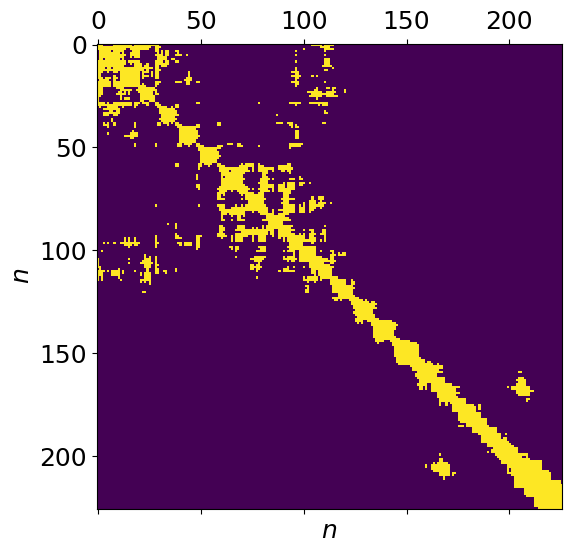

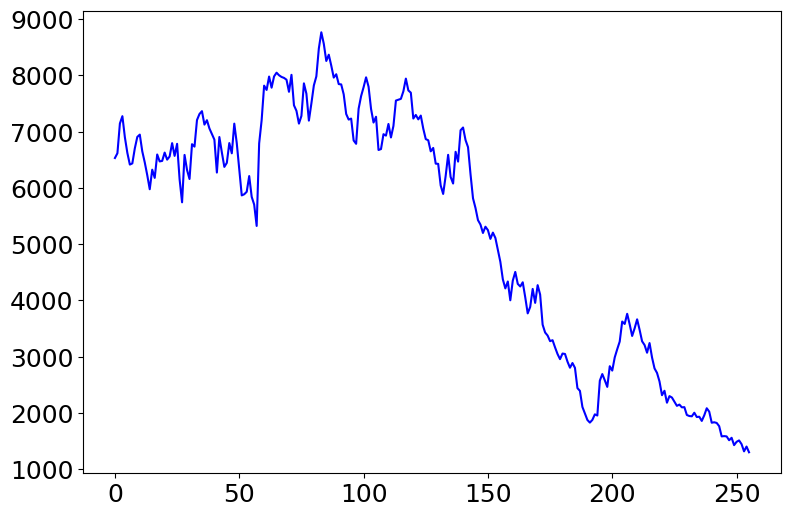

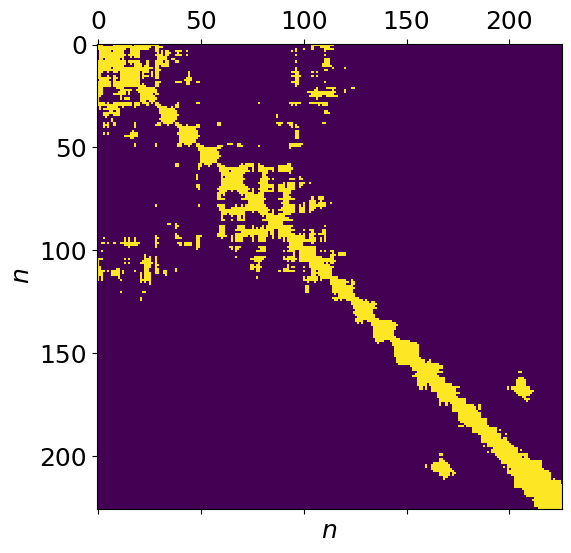

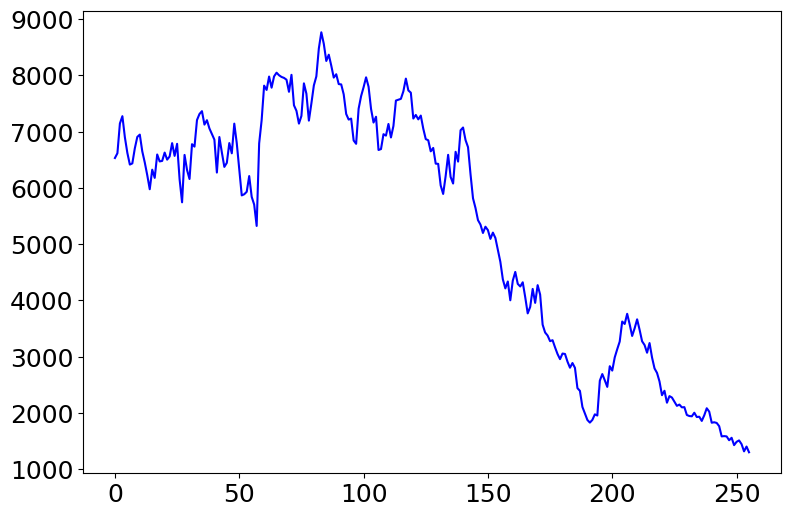

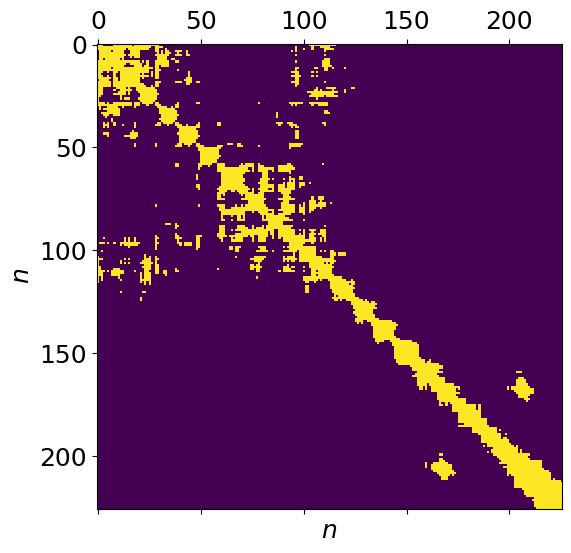

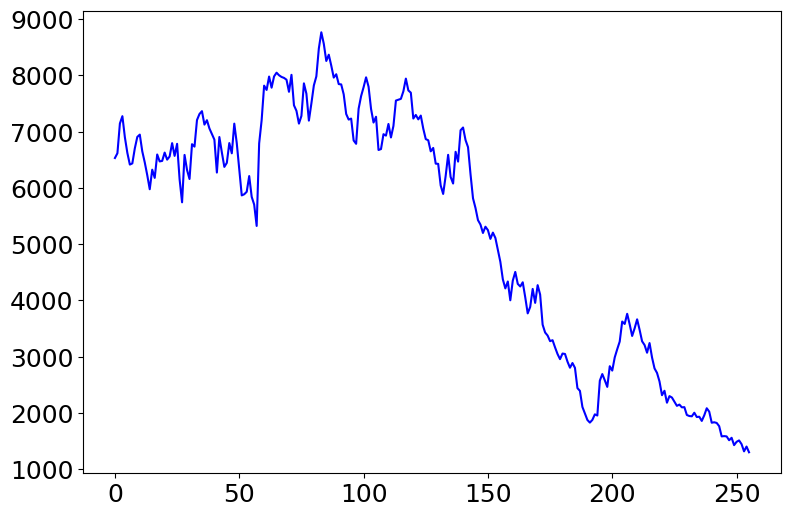

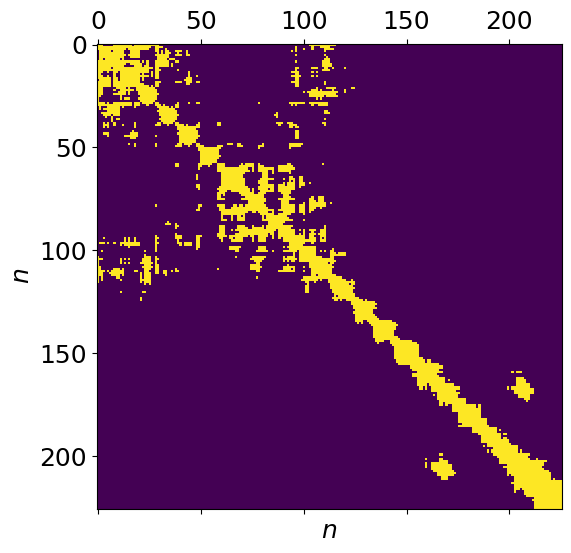

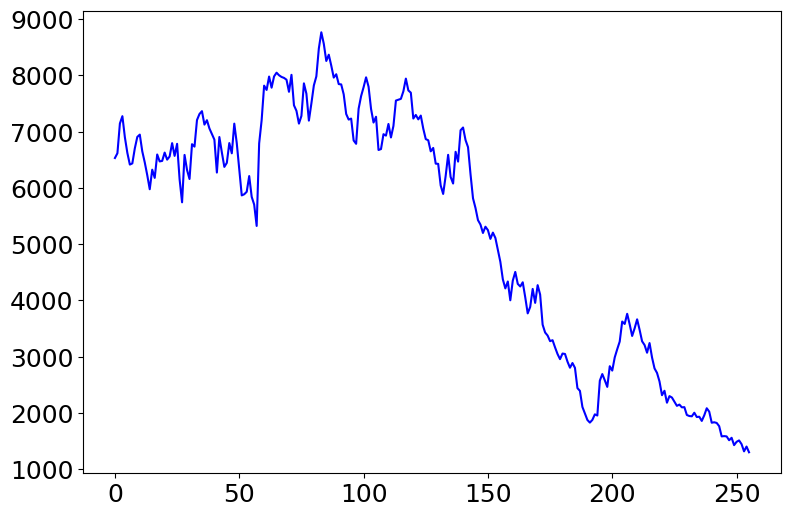

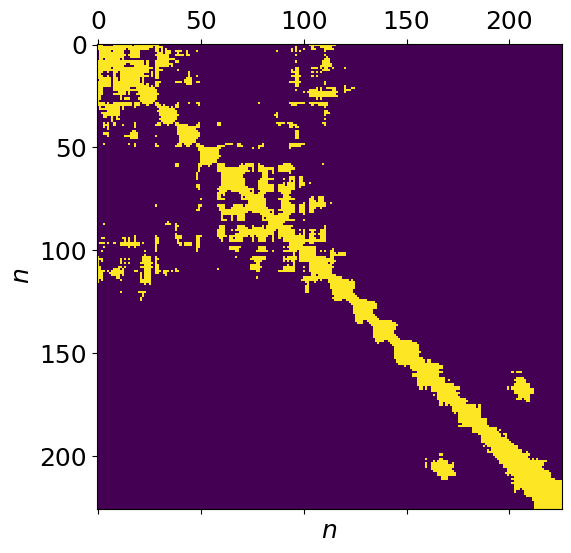

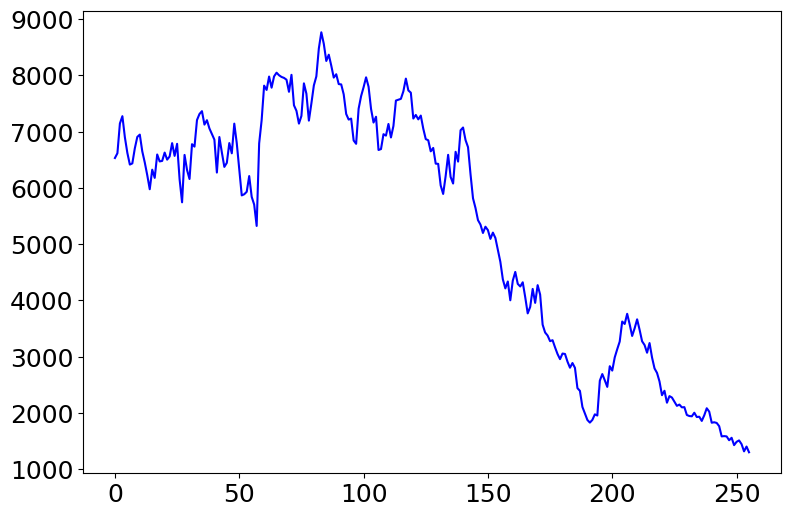

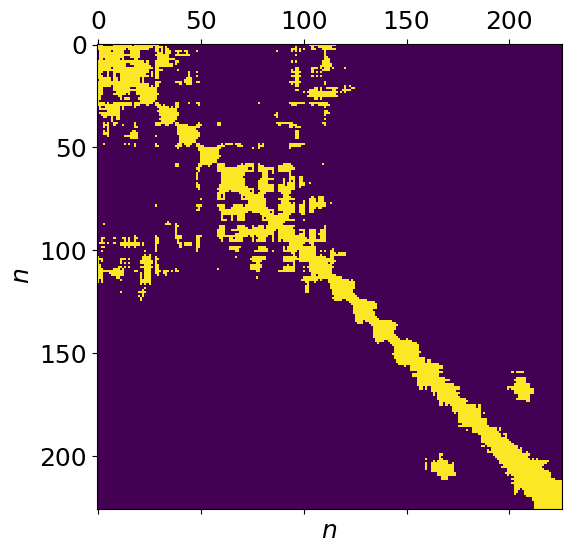

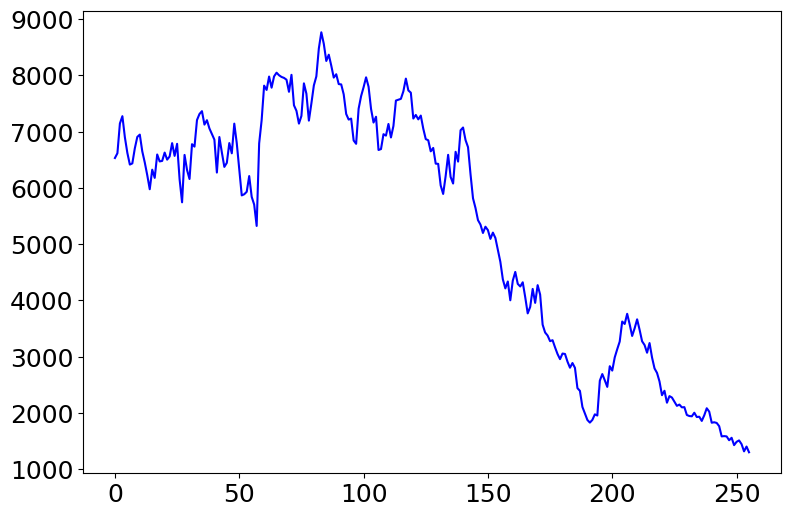

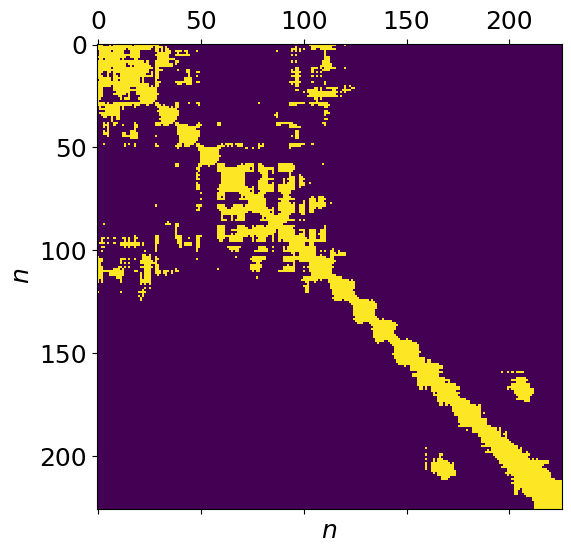

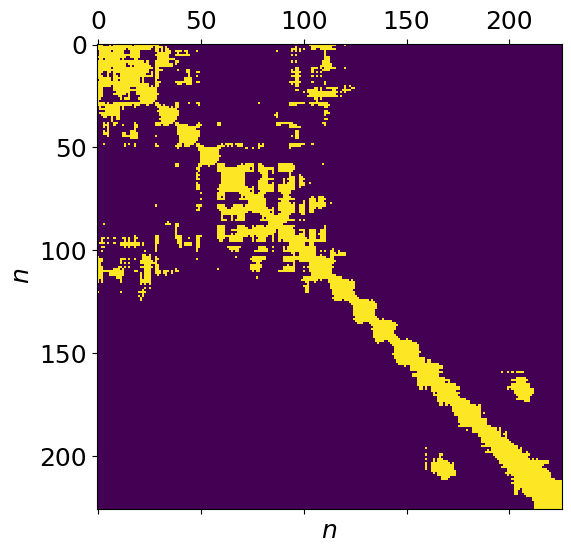

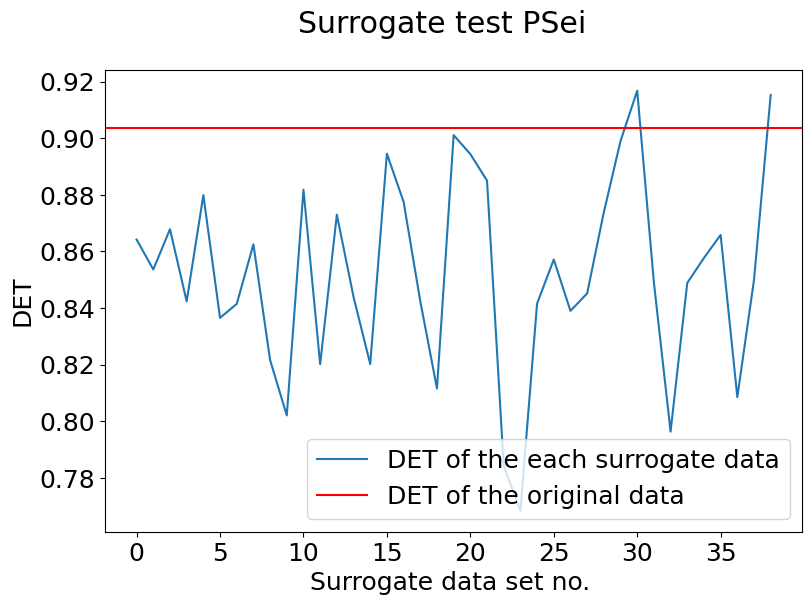

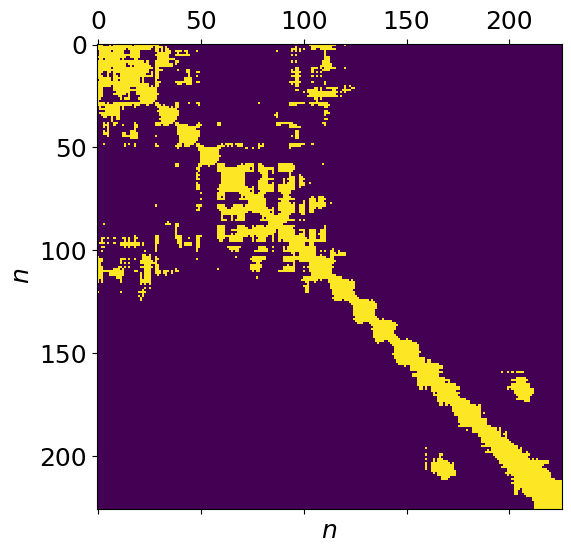

In [7]:
dimension=4
t_min=10
thr=0.2
k=data
s = lcurve(data)
det, rr = RP_RN(s, k)
while rr < 0.1:
    thr = thr + 0.01
    s = lcurve(k)
    det, rr = RP_RN(s, k)
    print(thr, rr)
os.system("./surrogates s/qp -n39 -o -V0")
RP_RN(s, k)
sur_test(s, k)

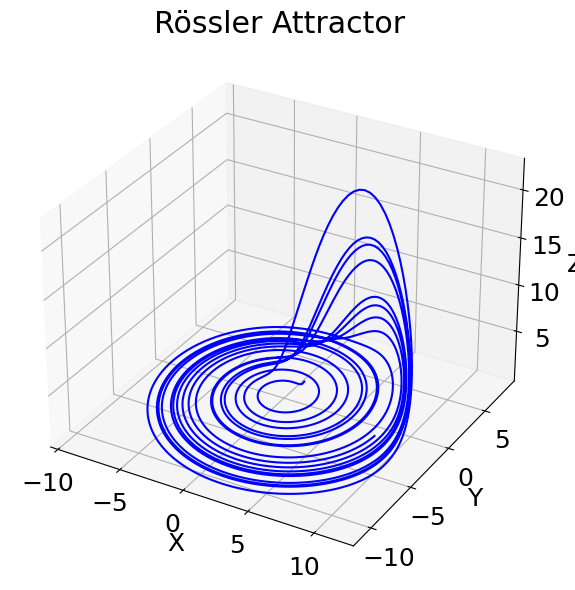

In [3]:
from scipy.integrate import solve_ivp

def rossler(t, state, a, b, c):
    x, y, z = state
    dxdt = -y - z
    dydt = x + a*y
    dzdt = b + z*(x - c)
    return [dxdt, dydt, dzdt]

# Parameters for the Rössler attractor
a = 0.2
b = 0.2
c = 5.7

# Initial conditions
initial_conditions = [1.0, 1.0, 1.0]

# Time span for the integration
t_span = (0, 100)

# Time points where we want the solution
t_eval = np.linspace(0, 100, 5000)

# Solve the system of differential equations
solution = solve_ivp(rossler, t_span, initial_conditions, t_eval=t_eval, args=(a, b, c))

# Extract the results
x_vals = solution.y[0]
y_vals = solution.y[1]
z_vals = solution.y[2]

# Plot the attractor
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_vals, y_vals, z_vals, color='blue')
ax.set_title("Rössler Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

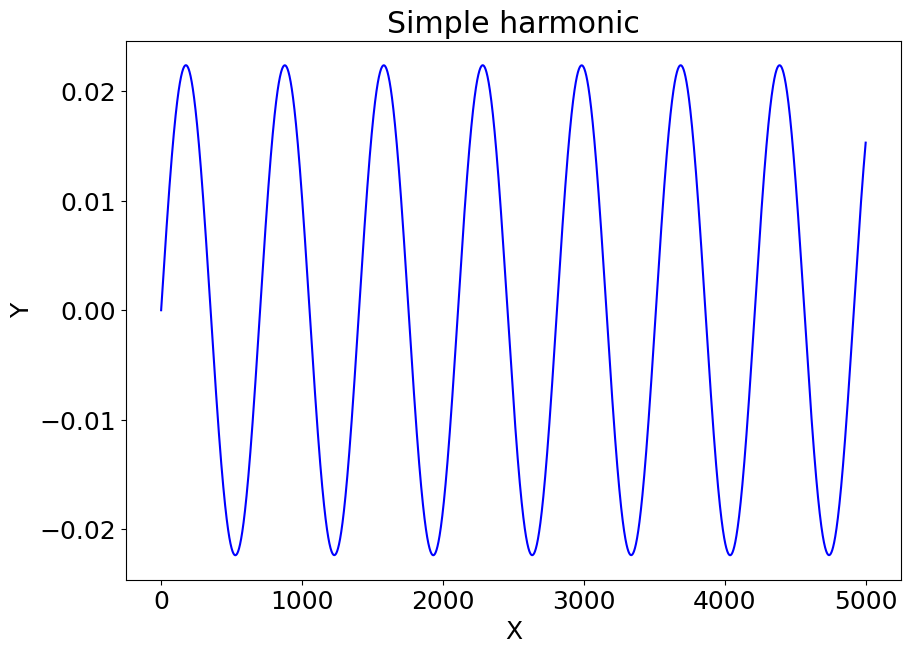

In [21]:
def harmonic(t, state, a, b):
    x, y = state
    dxdt = y
    dydt = -a*x/b
    return [dxdt, dydt]

# Parameters for the Rössler attractor
a = 2
b = 10

# Initial conditions
initial_conditions = [0, 0.01]

# Time span for the integration
t_span = (0, 100)

# Time points where we want the solution
t_eval = np.linspace(0, 100, 5000)

# Solve the system of differential equations
solution = solve_ivp(harmonic, t_span, initial_conditions, t_eval=t_eval, args=(a,b))

# Extract the results
x_vals = solution.y[0]
y_vals = solution.y[1]

# Plot the attractor
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)
ax.plot(x_vals,color='blue')
ax.set_title("Simple harmonic")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


Text(0, 0.5, '$n$')

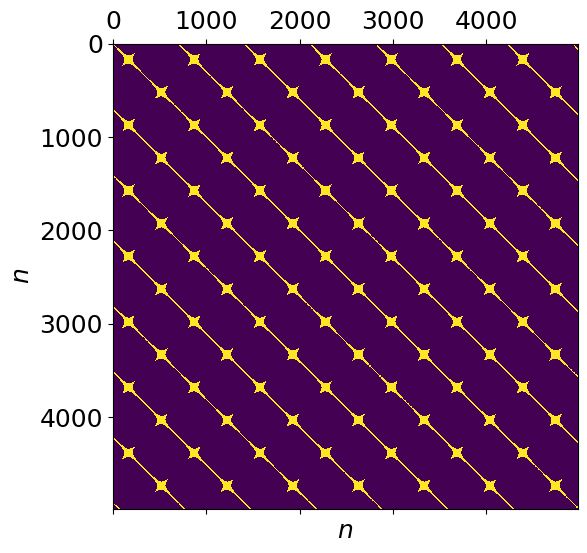

In [35]:
simple_rqa = RecurrencePlot(x_vals, dim=3, tau=10, metric = "euclidean", threshold=0.2, normalize=True)
pylab.matshow(simple_rqa.recurrence_matrix())
pylab.xlabel("$n$")
pylab.ylabel("$n$")


In [46]:
import random

# Generate a list of random numbers with potential duplicates
n = 5000  # Number of random numbers
li = random.choices(range(1, 101), k=n)
li = np.array(li, dtype=np.float32)


Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...


Text(0, 0.5, '$n$')

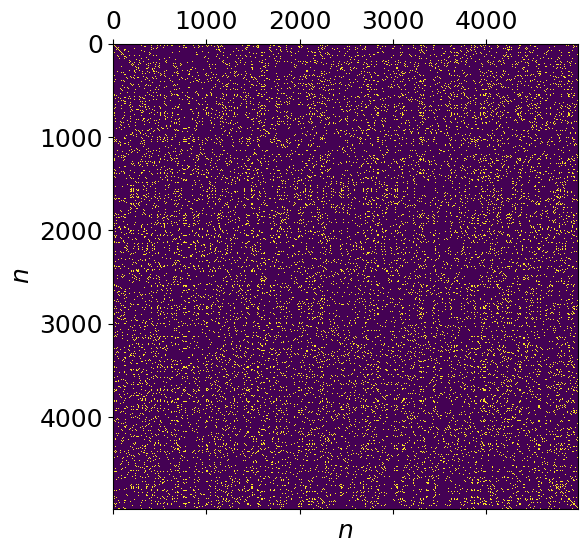

In [48]:
li_rqa = RecurrencePlot(li, dim=3, tau=10, metric = "euclidean", threshold=1, normalize=True)
pylab.matshow(li_rqa.recurrence_matrix())
pylab.xlabel("$n$")
pylab.ylabel("$n$")